In [68]:
# Eksplorasi E commerce churn

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import re
from datetime import datetime

from scipy.stats import mannwhitneyu

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, cross_validate

from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
import category_encoders as ce
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, precision_score, fbeta_score, make_scorer, ConfusionMatrixDisplay, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# **1. BACKGROUND**

Industri Online E-Commerce merupakan salah satu sektor dengan tingkat persaingan paling intens, dalam industri yang kompetitif ini, berdasarkan Harvard Business Review, mempertahankan pelanggan existing jauh lebih hemat biaya dibandingkan mengakuisisi pelanggan baru. Biaya akuisisi pelanggan (Customer Acquisition Cost / CAC) yang tinggi membuat churn menjadi isu bisnis yang kritikal. Setiap pelanggan yang churn tidak hanya menyebabkan hilangnya pendapatan saat ini, tetapi juga potensi pendapatan jangka panjang.
(https://hbr.org/2014/10/the-value-of-keeping-the-right-customers).

Dataset ini mencakup perilaku pelanggan online e-commerce, mulai dari demografi, interaksi aplikasi (seperti HourSpendOnApp), hingga riwayat transaksi. Fokus utama perusahaan adalah memastikan pelanggan tetap aktif berbelanja di platform dan tidak berpindah ke kompetitor lain dimana perusahaan online e-commerce ini memilih untuk menekan pengeluaran yang tidak tepat sasaran. 

Fenomena Customer Churn, yaitu kondisi ketika pelanggan berhenti bertransaksi atau beralih ke kompetitor dalam periode tertentu, merupakan ancaman laten yang sering kali tidak terdeteksi sejak dini. Dalam konteks dataset E-Commerce yang digunakan pada proyek ini, churn tidak hanya mencerminkan penurunan aktivitas transaksi, tetapi juga kegagalan perusahaan dalam membangun pengalaman pelanggan yang berkelanjutan (sustainable customer experience).
Analisis awal terhadap data mengindikasikan bahwa loyalitas pelanggan tidak semata-mata ditentukan oleh faktor harga. Sebaliknya, churn dipengaruhi oleh kombinasi beberapa faktor seperti:

- Masa Langganan (Tenure): Tenure pendek bisa menunjukkan kecenderungan pelanggan baru cenderung lebih rentan untuk churn dibandingkan pelanggan lama yang sudah memiliki trust.
- Faktor Keluhan (Complain): Pelanggan yang menyampaikan keluhan memiliki risiko churn yang jauh lebih tinggi jika tidak ditangani dengan strategi recovery yang cepat.
- Insentif vs Loyalitas: Perusahaan mengeluarkan biaya besar untuk cashback, namun perlu dievaluasi apakah pemberian subsidi ini benar-benar efektif menahan pelanggan atau justru membebani margin perusahaan.
- Keadaan Logistik: Jarak antara gudang ke rumah pelanggan `WarehouseToHome` menjadi variabel krusial yang mempengaruhi kecepatan pengiriman dan kepuasan pelanggan.

Kegagalan dalam memprediksi churn secara dini menyebabkan tim marketing terus melakukan promosi "buta" kepada semua orang, yang mengakibatkan inefisiensi anggaran dan rendahnya Return on Investment (ROI) dari program retensi.



# **2. PROBLEM STATEMENT**

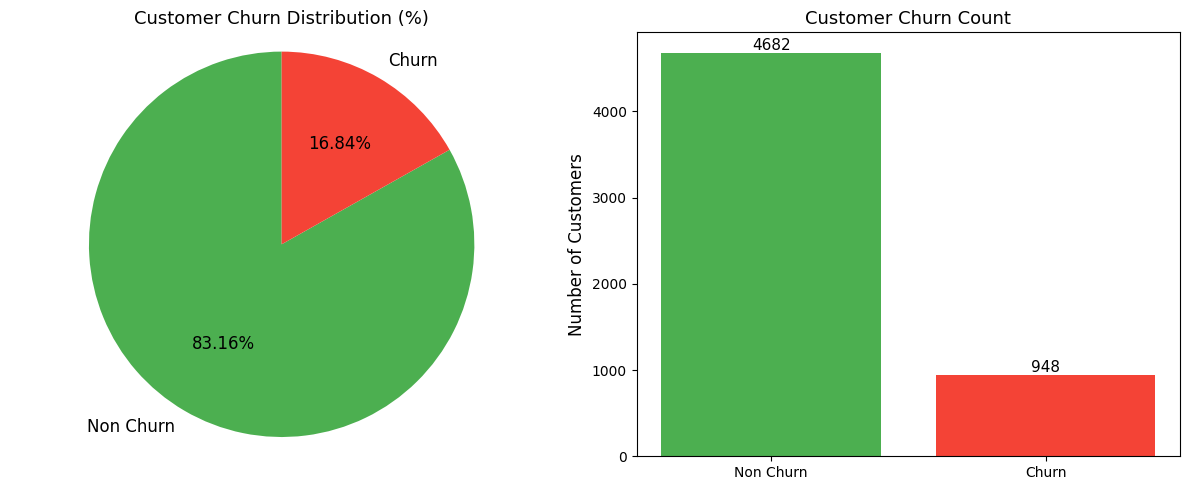


Berdasarkan (https://kiriminaja.com/blog/tingkat-customer-churn-sehat), churn rate adalah persentase pelanggan yang berhenti beli dalam periode tertentu. Kondisi churn rate yang sehat berada pada kisaran angka 5-8% sedangkan churn rate pada dataset ini ada di angka 16.84% sehingga nilai churn rate pada dataset ini dinilai tidak sehat. 

`Masalah: Kondisi Churn Rate yang melebihi ambang batas normal retail online e-commerce.`

**Risiko Bisnis:** `Jika perusahaan memberikan promo ke semua orang tanpa target, akan terjadi pemborosan biaya pemasaran. Sebaliknya, jika perusahaan gagal mendeteksi pelanggan yang akan pergi, pangsa pasar akan menurun.`



# **3. GOALS**

`Goals Utama: Membangun sistem prediksi churn yang akurat untuk mengidentifikasi pelanggan churn dan faktor-faktor yang mempengaruhi fenomena churn untuk meminimalisir pelanggan churn.`

Pencapaian yang diperlukan:
1.	**Profiling Pelanggan High Risk (Churn):** Memetakan karakteristik demografi dan perilaku (seperti kategori produk favorit, jarak rumah, dan jumlah perangkat) yang menjadi indikator kuat churn.
2.	**Mengidentifikasi variabel-variabel kunci yang berkontribusi terhadap churn pelanggan:** Optimalisasi dalam alokasi pengeluaran yang berdampak besar selain pemberian cashback. 
3.	**Service Recovery Strategy:** Menyusun rekomendasi untuk tim operasional mengenai penanganan pelanggan yang melakukan Complain berdasarkan tingkat risiko churn mereka.

# **4. ANALYTICAL APPROACH**

Pendekatan analitik dilakukan secara sistematis dengan fokus pada efisiensi pengolahan data tanpa mengurangi akurasi prediksi:

Pertama, Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik churn. Kami menganalisis distribusi variabel kunci seperti Tenure dan Complain untuk menemukan tipping point di mana pelanggan mulai menunjukkan tanda-tanda ketidakpuasan. Kami juga mengevaluasi hubungan antara jarak logistik (WarehouseToHome) dengan frekuensi komplain untuk memetakan risiko operasional.

Kedua, Manual Data Imputation & Cleaning. Alih-alih menggunakan algoritma stokastik, kami menerapkan imputasi manual yang berbasis konteks data:
- Tenure: Nilai kosong dan NaN diisi dengan Median berdasarkan kelompok `CityTier`, karena lama berlangganan seringkali memiliki pola serupa dalam tingkatan ekonomi kota yang sama.
- `WarehouseToHome` & `DaySinceLastOrder`: Pengisian NaN Menggunakan Median global untuk menghindari pengaruh pencilan (outliers) yang ekstrim.
- Inconsistency Handling: Melakukan penyeragaman label pada kategori yang tumpang tindih seperti mengubah 'CC' menjadi 'Credit Card' dan 'Mobile Phone' menjadi 'Mobile'.

Ketiga, Pemodelan Prediktif. Kami menggunakan algoritma base model seerta ensemble tingkat lanjut yaitu XGBoost dan Random Forest. 
Untuk menangani ketidakseimbangan data (di mana kelas churn jauh lebih sedikit), kami menggunakan teknik SMOTE di dalam Pipeline sebelum tahap pelatihan model.

# **5. METRICS EVALUATION**

Dalam klasifikasi churn, nilai akurasi sering kali membingungkan. Kami menggunakan pendekatan Cost-Benefit Analysis melalui Confusion Matrix untuk menentukan metrik terbaik bagi profitabilitas perusahaan.

Untuk memahaminya secara mendalam, kita menggunakan Confusion Matrix sebagai dasar perhitungan. Dalam kasus ini, kita mendefinisikan:

- Positif (1): Pelanggan yang Churn (Berhenti belanja/meninggalkan platform).

- negatif (0): Pelanggan yang Non Churn (Tetap setia/aktif belanja).

Confusion Matrix membagi hasil prediksi model menjadi empat komponen utama:

| Komponen                | Definisi                         | Dampak Bisnis                                                                                         | Biaya                             |
| ----------------------- | -------------------------------- | ----------------------------------------------------------------------------------------------------- | --------------------------------- |
| **True Positive (TP)**  | Prediksi *Churn*, Aktual *Churn* | **Sukses**: Intervensi retensi dilakukan tepat waktu sehingga pelanggan berhasil dipertahankan        | Biaya Promo (Kecil)               |
| **True Negative (TN)**  | Prediksi *Non Churn*, Aktual *Non Churn*   | **Efisiensi**: Tidak mengalokasikan promo pada pelanggan yang memang loyal                            | Rp 0                              |
| **False Positive (FP)** | Prediksi *Churn*, Aktual *Non Churn*  | **Inefisiensi**: Diskon atau insentif diberikan kepada pelanggan yang sebenarnya tidak berisiko churn | Biaya Promo (Marginal)            |
| **False Negative (FN)** | Prediksi *Non Churn*, Aktual *Churn*  | **Kegagalan**: Pelanggan bernilai tinggi hilang tanpa sempat dilakukan pencegahan                     | Lost Revenue + CAC (Sangat Besar) |

Dampak paling besar: False Negative (FN)

Oleh karena itu, 
**(Metrik Utama) = F2 Score** Karena prioritas kami adalah meminimalkan False Negative.

`“Lebih baik memberikan voucher kepada 10 orang setia (FP) daripada kehilangan 1 pelanggan berharga selamanya (FN).” Recall yang tinggi memastikan sistem Early Warning kita menangkap sebanyak mungkin calon churner.`

## **DATA UNDERSTANDING**

**Dataset source:** 

https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction

**Data Information:**

| Variable                    | Description                       | Business Relevance to Churn                                     |
| --------------------------- | --------------------------------- | --------------------------------------------------------------- |
| CustomerID                  | Unique customer identifier        | Identifier unik, **tidak digunakan sebagai fitur model**        |
| Churn                       | Churn flag                        | **Target variable** (1 = churn, 0 = tidak churn)                |
| Tenure                      | Lama pelanggan bergabung (bulan)  | Pelanggan baru biasanya **lebih rentan churn**                  |
| PreferredLoginDevice        | Perangkat login utama             | UX pada device tertentu dapat memengaruhi churn                 |
| CityTier                    | Tingkatan kota                    | Akses logistik & kualitas layanan memengaruhi loyalitas         |
| WarehouseToHome             | Jarak gudang ke rumah             | Jarak jauh → pengiriman lebih lama → **risiko churn meningkat** |
| PreferredPaymentMode        | Metode pembayaran favorit         | Metode terbatas dapat menurunkan kenyamanan                     |
| Gender                      | Gender pelanggan                  | Faktor demografis pendukung                                     |
| HourSpendOnApp              | Jam penggunaan aplikasi/web       | Engagement rendah = **indikasi churn**                          |
| NumberOfDeviceRegistered    | Jumlah device terdaftar           | Multi-device menandakan engagement lebih tinggi                 |
| PreferedOrderCat            | Kategori pesanan favorit          | Preferensi produk memengaruhi retensi                           |
| SatisfactionScore           | Skor kepuasan layanan             | **Salah satu indikator churn terkuat**                          |
| MaritalStatus               | Status pernikahan                 | Faktor demografis pendukung                                     |
| NumberOfAddress             | Jumlah alamat tersimpan           | Lebih banyak alamat = **pelanggan lebih loyal**                 |
| Complain                    | Keluhan dalam 1 bulan terakhir    | Keluhan → **risiko churn tinggi**                               |
| OrderAmountHikeFromlastYear | Kenaikan nilai order (%)          | Membedakan pelanggan bertumbuh vs stagnan                       |
| CouponUsed                  | Jumlah kupon digunakan            | Menggambarkan sensitivitas terhadap promo                       |
| OrderCount                  | Jumlah order bulan terakhir       | Tingkat aktivitas transaksi                                     |
| DaySinceLastOrder           | Hari sejak order terakhir         | Recency tinggi = **churn risk meningkat**                       |
| CashbackAmount              | Rata-rata cashback bulan terakhir | Mengukur efektivitas insentif                                   |


In [69]:
df = pd.read_excel("ecommerce_churn.xlsx")
df.head(10)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [70]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

## **GENERAL INFORMATION**

In [71]:
# Analisis Deskriptif

display(df.head())
display(df.info())

# Proporsi Pelanggan Churn

print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

None

Churn
0    4682
1     948
Name: count, dtype: int64
Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


In [72]:
df['CityTier'] = df['CityTier'].astype('category')
df['Churn'] = df['Churn'].astype('category')
df['Complain'] = df['Complain'].astype('category')


display(df.describe(include=['category', 'object']).T)

,count,unique,top,freq
Churn,5630,2,0,4682
PreferredLoginDevice,5630,3,Mobile Phone,2765
CityTier,5630,3,1,3666
PreferredPaymentMode,5630,7,Debit Card,2314
Gender,5630,2,Male,3384
PreferedOrderCat,5630,6,Laptop & Accessory,2050
MaritalStatus,5630,3,Married,2986
Complain,5630,2,0,4026


In [73]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
OrderAmountHikeFromlastYear,5365.0,15.707922,3.675485,11.0,13.00,15.00,18.0000,26.00
CouponUsed,5374.0,1.751023,1.894621,0.0,1.00,1.00,2.0000,16.00
OrderCount,5372.0,3.008004,2.939680,1.0,1.00,2.00,3.0000,16.00


# **ANALISIS DESKRIPTIF**

## Gambaran Umum Dataset & Prediksi Probabilitas

Dataset ini terdiri dari **5.630 pelanggan**, di mana setiap baris merepresentasikan satu pelanggan e-commerce. 
Dataset mencakup informasi demografis, perilaku penggunaan aplikasi, aktivitas transaksi, kepuasan pelanggan, logistik, serta status **Customer Churn** sebesar 16,8%

**Analisis Kolom**
1. Tenure (Masa Berlangganan)
- Rata-rata: **10,19 bulan**
- Minimum: **0 bulan**
- Maksimum: **61 bulan**

Mayoritas pelanggan masih berada pada fase awal–menengah siklus hidup. Pelanggan dengan **tenure rendah** berpotensi lebih rentan terhadap churn karena loyalitas belum terbentuk.

2. WarehouseToHome (Jarak Gudang ke Rumah)
- Rata-rata: **15,64 km**
- Minimum: **5 km**
- Maksimum: **127 km**

Variasi jarak yang besar menunjukkan potensi perbedaan kualitas layanan logistik. Jarak yang jauh berpotensi meningkatkan keterlambatan pengiriman dan risiko churn.

3. HourSpendOnApp (Waktu Penggunaan Aplikasi)
- Rata-rata: **2,93 jam/hari**
- Minimum: **0 jam**
- Maksimum: **5 jam**

Durasi penggunaan mencerminkan engagement pelanggan. Penurunan waktu penggunaan dapat menjadi sinyal awal churn.

4. NumberOfDeviceRegistered
- Rata-rata: **3,69 perangkat**
- Rentang: **1-6 perangkat**

Jumlah perangkat yang lebih banyak mengindikasikan keterikatan (engagement) yang lebih tinggi terhadap platform.

5. SatisfactionScore (Skor Kepuasan)
- Skala: **1-5**
- Rata-rata: **3,07**
- Minimum: **1**

Skor kepuasan berada pada tingkat sedang. Pelanggan dengan skor rendah berpotensi memiliki risiko churn lebih tinggi, terutama jika disertai keluhan.

- Selain itu, mayoritas pelanggan berasal dari `CityTier` 1 dan 2 (rata-rata 1,65), menunjukkan dominasi wilayah metropolitan dan kota berkembang yang berpotensi memengaruhi churn melalui perbedaan daya beli, ekspektasi layanan, dan kualitas logistik mengalahkan CityTier 3. Mobile Phone menjadi perangkat login utama, menegaskan pentingnya optimalisasi UX aplikasi mobile untuk memudahkan penggunaan. Metode pembayaran paling umum adalah Debit Card, yang berperan dalam kenyamanan transaksi. Sekitar 28% pelanggan pernah melakukan complain, menjadikannya indikator kuat risiko churn jika tidak ditangani dengan baik. Beberapa variabel penting seperti **Tenure, WarehouseToHome, HourSpendOnApp, dan DaySinceLastOrder** memiliki missing value dalam proporsi kecil, sehingga imputation median lebih tepat dibandingkan penghapusan data untuk menjaga kualitas analisis dan pemodelan.

**Note: median digunakan untuk imputasi karena nilai mean dan median rata-rata sangat dekat dan lebih baik jika fitur-fitur memiliki value yang berupa integer. 


## **Data Cleaning**

In [74]:
# Periksa Missing Value
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [75]:
# Handle Missing Value 
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        
# Periksa Ulang Missing Value
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [76]:
# Cek Duplikasi Data
df.duplicated().sum()

np.int64(0)

**Explanation:** Tidak ada duplikasi nilai pada data.

In [77]:
df.drop(['CustomerID'],axis=1, inplace=True)

**Explanation:** Kolom tidak diperlukan. 

In [78]:
# Cek Duplikasi Kolom
cat_columns = df.select_dtypes(include=['object']).columns

for col in cat_columns:
    print(f"- Kolom: {col} -")
    print(f"Jumlah Unique: {df[col].nunique()}")
    print(f"Nilai: {df[col].unique()}")
    print("\n")

- Kolom: PreferredLoginDevice -
Jumlah Unique: 3
Nilai: ['Mobile Phone' 'Phone' 'Computer']


- Kolom: PreferredPaymentMode -
Jumlah Unique: 7
Nilai: ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']


- Kolom: Gender -
Jumlah Unique: 2
Nilai: ['Female' 'Male']


- Kolom: PreferedOrderCat -
Jumlah Unique: 6
Nilai: ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']


- Kolom: MaritalStatus -
Jumlah Unique: 3
Nilai: ['Single' 'Divorced' 'Married']




# **Exploration Data Analysis & Data Visualization**

### **Univariate Analysis - Kategorikal**

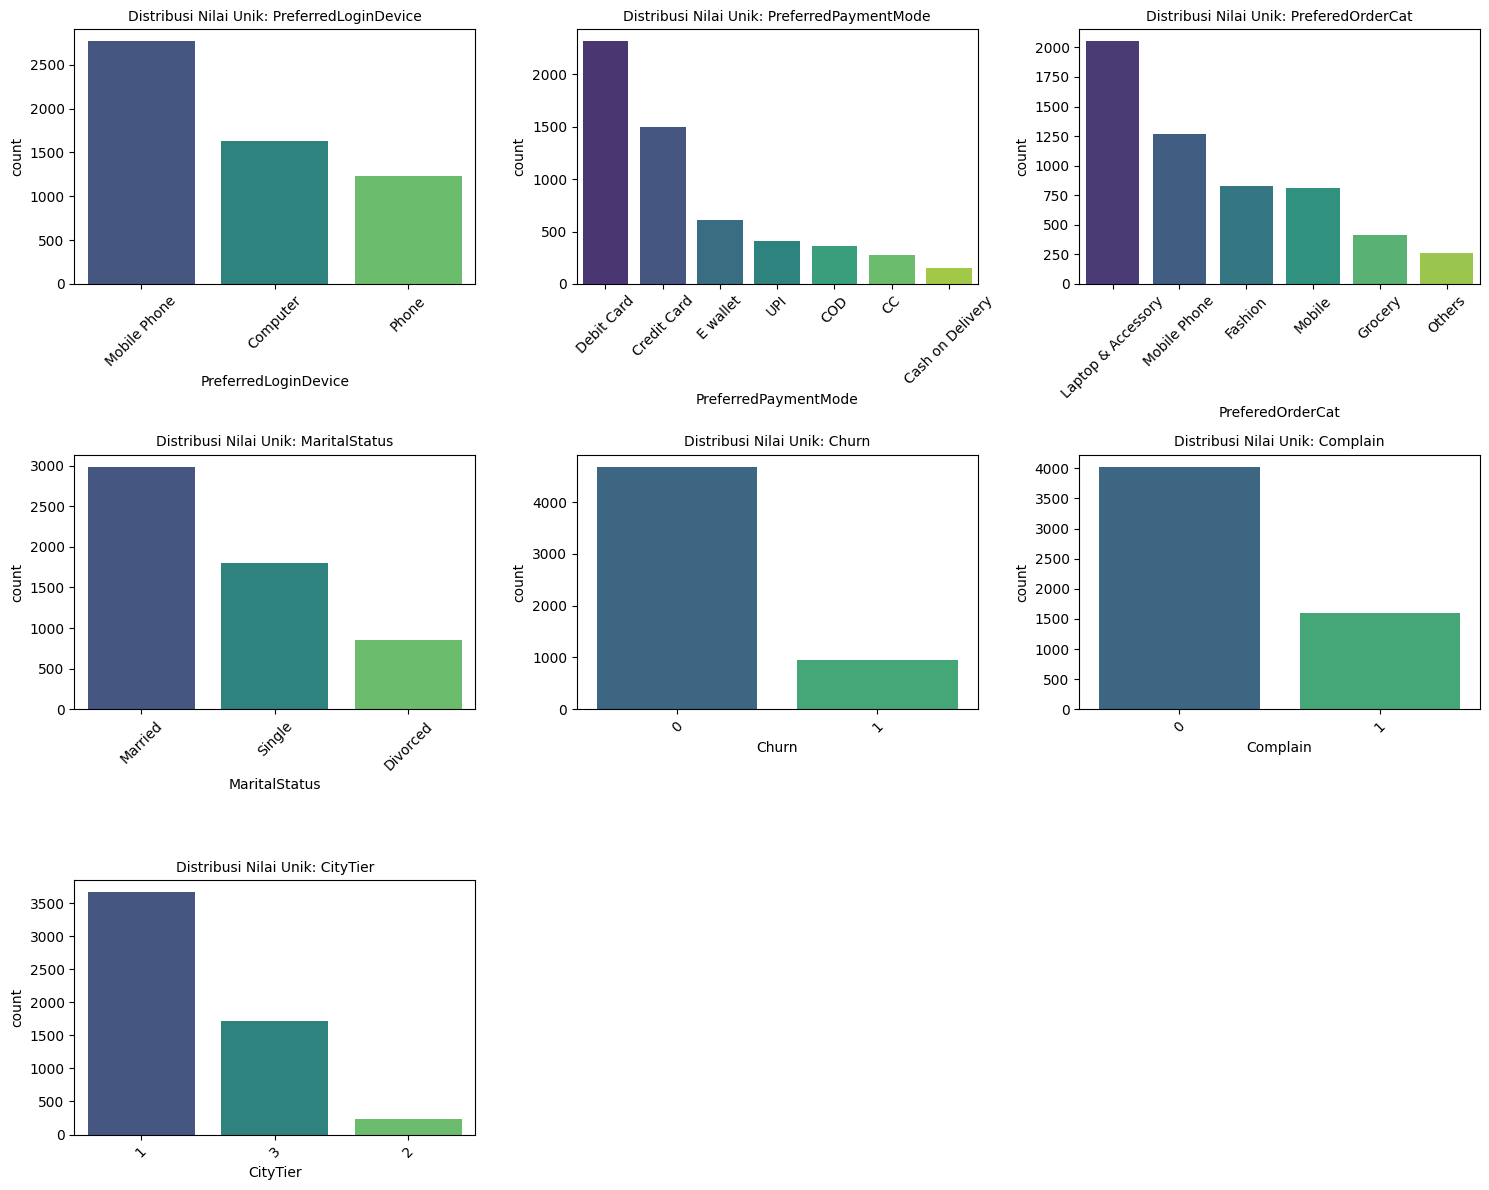

In [79]:
# Visualisasi unique values untuk 4 kolom kategori utama

cat_plot = [
    'PreferredLoginDevice', 'PreferredPaymentMode',
    'PreferedOrderCat', 'MaritalStatus',
    'Churn', 'Complain', 'CityTier'
]

n_cols = 3
n_rows = int(np.ceil(len(cat_plot) / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(cat_plot, 1):
    plt.subplot(n_rows, n_cols, i)

    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='viridis')

    plt.title(f'Distribusi Nilai Unik: {col}', fontsize=10)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**Explanation:** Pada dataset ini ditemukan inkonsistensi penamaan kategori yang dapat menimbulkan noise pada analisis dan pemodelan. Selanjutnya akan diatasi pada kolom `PreferredLoginDevice`, kategori Phone digabungkan ke dalam Mobile Phone karena memiliki makna yang sama. Tambahan, pada `PreferredPaymentMode`, beberapa singkatan seperti CC dan COD diseragamkan menjadi Credit Card dan Cash on Delivery agar preferensi metode pembayaran dapat dianalisis secara lebih akurat. Selain itu, pada `PreferedOrderCat`, kategori Mobile disatukan dengan Mobile Phone untuk menghindari duplikasi kategori produk. Proses ini bertujuan untuk meningkatkan konsistensi data, mengurangi jumlah kategori yang tidak perlu, serta memastikan kualitas fitur sebelum tahap encoding dan pemodelan machine learning.

In [80]:
# Mapping Data 

# 1. Merapikan PreferredLoginDevice
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Phone', 'Mobile Phone')

# 2. Merapikan PreferredPaymentMode
# Menyatukan singkatan ke nama lengkap atau sebaliknya agar konsisten
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery',
})

# 3. Merapikan PreferedOrderCat
# Terkadang ada typo atau kategori yang sangat mirip (cek unique Anda)
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

# Cek hasil setelah re-mapping
for col in ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat']:
    print(f"Unique {col}: {df[col].unique()}")


Unique PreferredLoginDevice: ['Mobile Phone' 'Computer']
Unique PreferredPaymentMode: ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet']
Unique PreferedOrderCat: ['Laptop & Accessory' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']


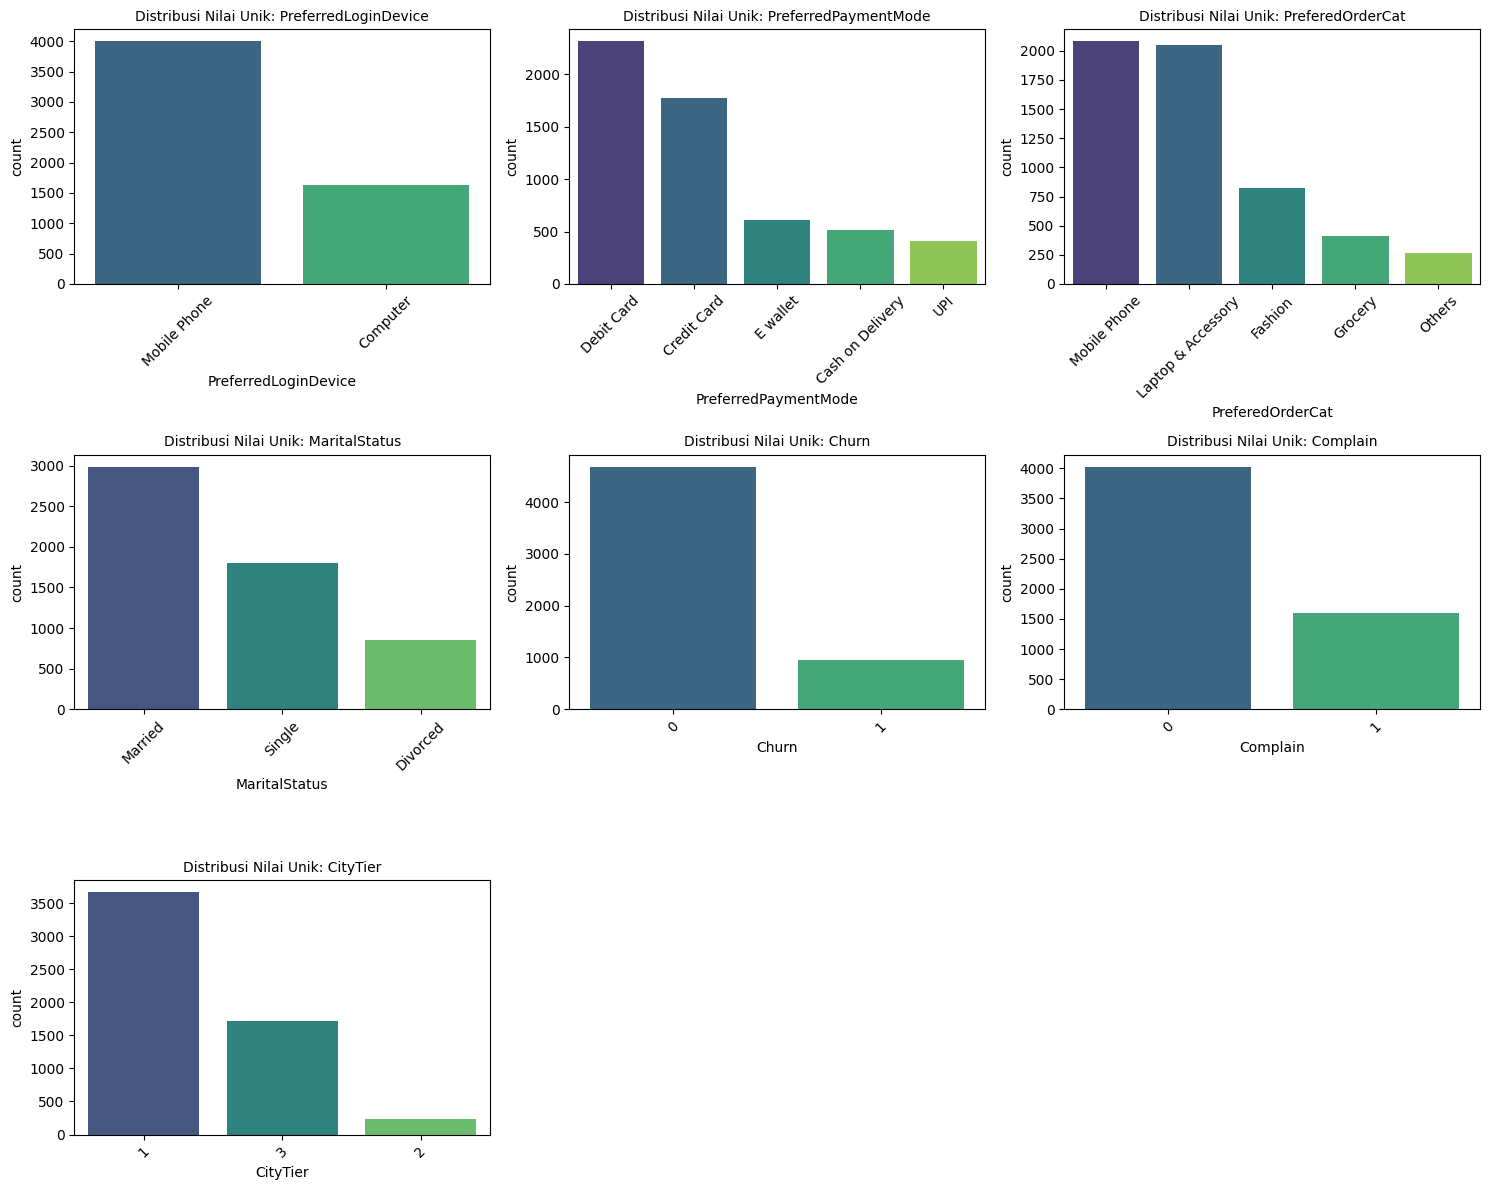

In [81]:
n_cols = 3
n_rows = int(np.ceil(len(cat_plot) / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(cat_plot, 1):
    plt.subplot(n_rows, n_cols, i)

    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='viridis')

    plt.title(f'Distribusi Nilai Unik: {col}', fontsize=10)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Explanation:** Setelah diperbaiki, nilai-nilai tiap kategori juga berubah. 

### **Univariate Analysis - Numerikal**

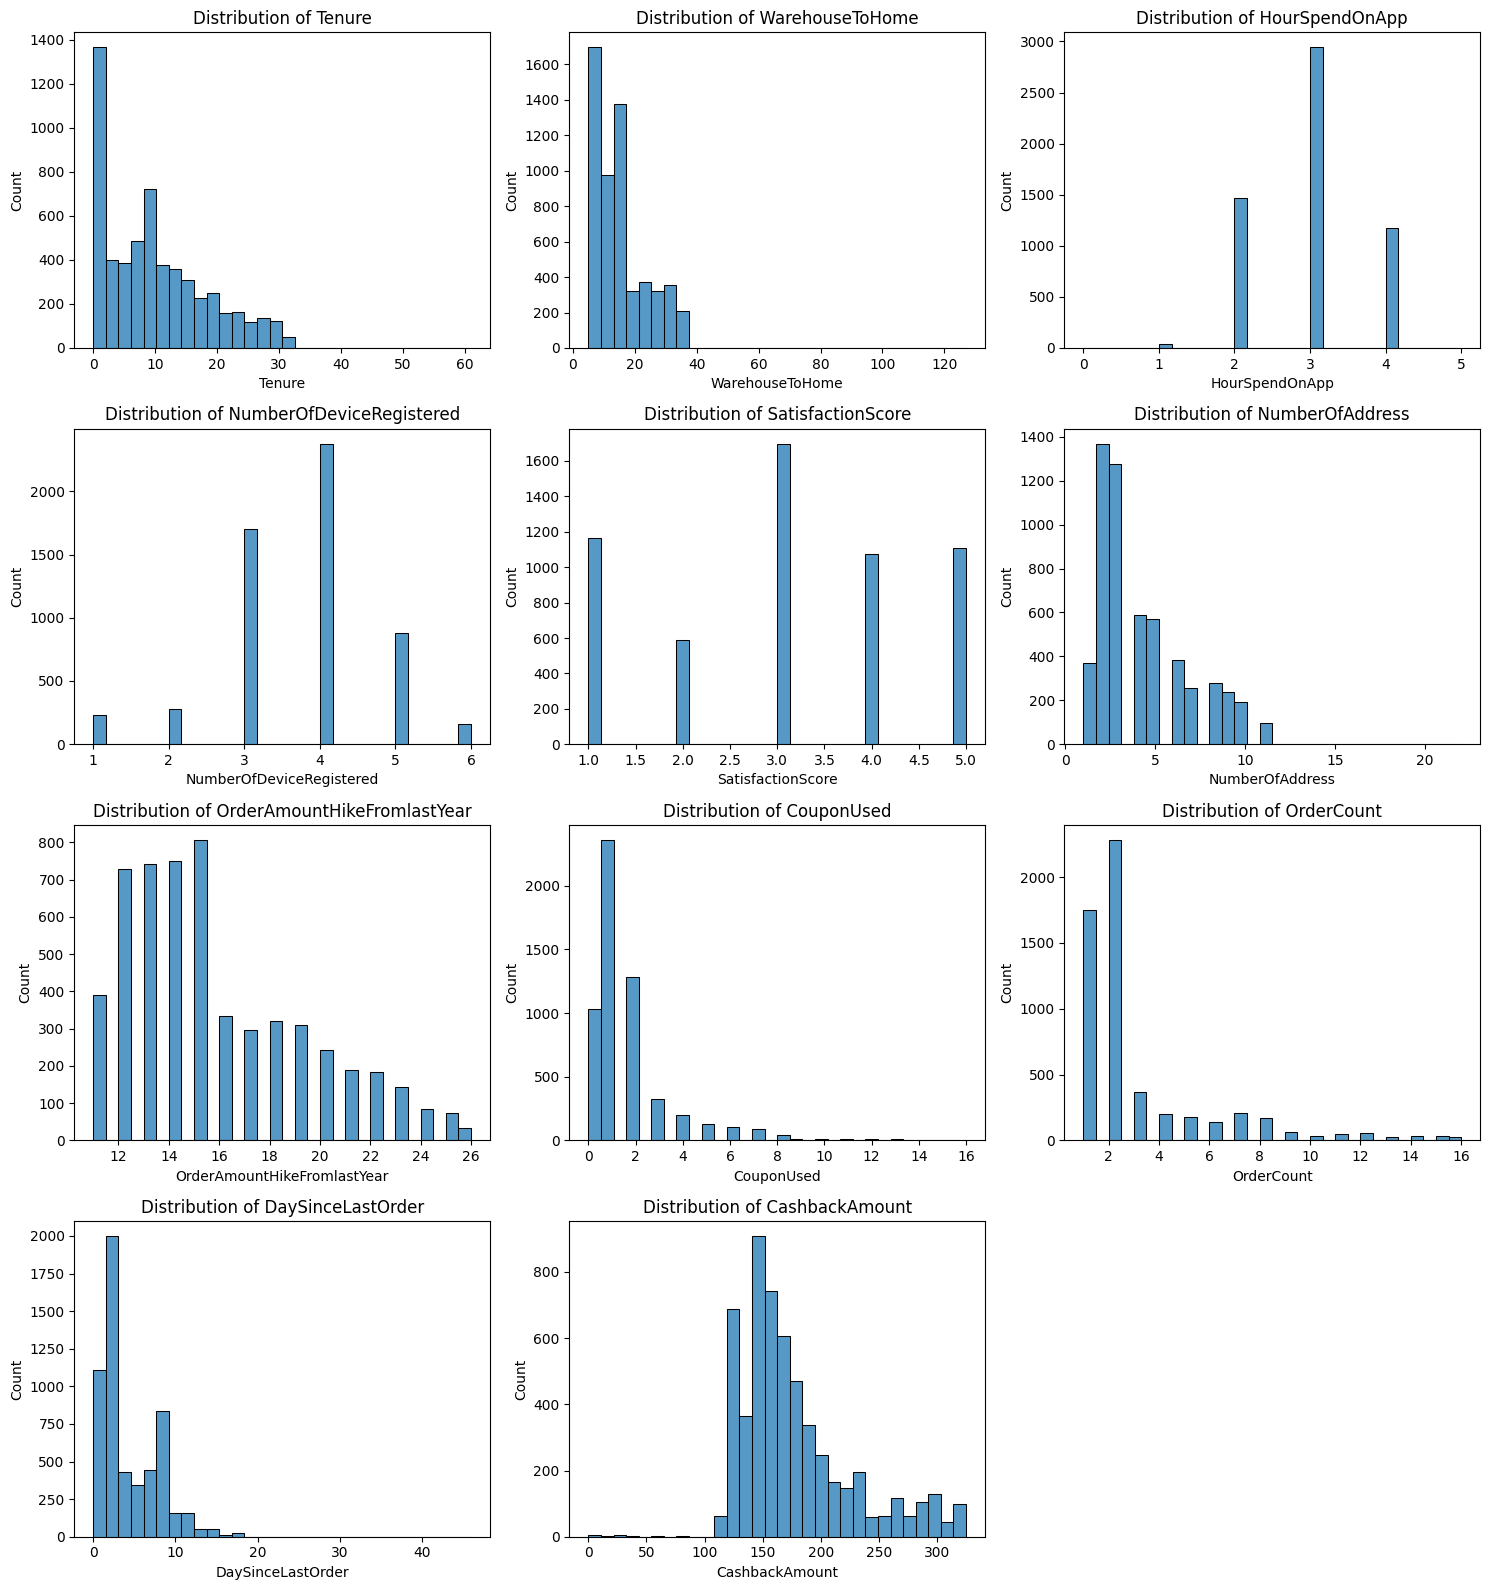

In [82]:
# Univariate Analysis

num_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = 3  
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [83]:
from scipy.stats import shapiro

num_cols = df.select_dtypes(include='number').columns

results = []

for col in num_cols:
    stat, p = shapiro(df[col].dropna())
    results.append({
        'Column': col,
        'p_value': p,
        'Normal': p > 0.05
    })

normality_df = pd.DataFrame(results)
normality_df

,Column,p_value,Normal
0,Tenure,5.520309e-47,False
1,WarehouseToHome,1.931021e-57,False
2,HourSpendOnApp,9.426686e-62,False
3,NumberOfDeviceRegistered,7.767200e-52,False
4,SatisfactionScore,1.186692e-53,False
5,NumberOfAddress,4.609121e-55,False
6,OrderAmountHikeFromlastYear,2.024211e-48,False
7,CouponUsed,5.399640e-71,False
8,OrderCount,2.284921e-74,False
9,DaySinceLastOrder,1.024041e-52,False


**Explanation:** 

Dari visualisasi dan uji normalitas variabel numerik, dapat disimpulkan bahwa semua variabel numerik merupakan variabel non-parametrik (tidak berdistribusi normal). Oleh karena itu, central tendency yang kita gunakan untuk data tersebut adalah median.

- Tenure condong ke kanan menunjukkan banyak pelanggan masih relatif baru
- CashbackAmount memiliki variasi besar memberi gambaran potensi overspending promosi
- DaySinceLastOrder memiliki `long-tail` atau ekor panjang → sinyal pelanggan tidak aktif

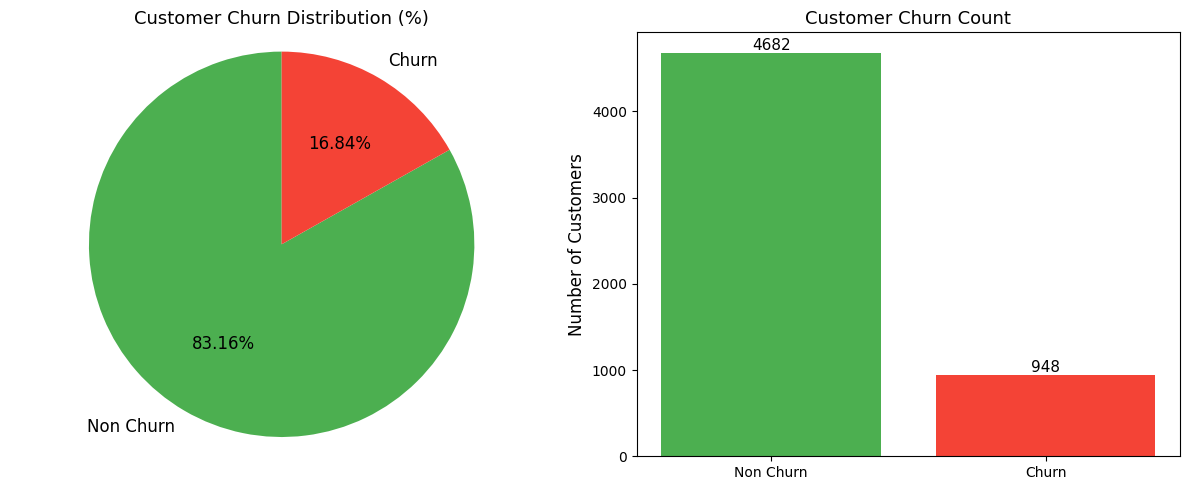

In [84]:
# Data
churn_count = df['Churn'].value_counts().sort_index()
churn_pct = df['Churn'].value_counts(normalize=True).sort_index() * 100

colors = ['#4CAF50', '#F44336']  # hijau = Non Churn, merah = Churn
labels = ['Non Churn', 'Churn']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# === Pie Chart ===
axes[0].pie(
    churn_pct,
    labels=labels,
    autopct='%.2f%%',
    startangle=90,
    textprops={'fontsize': 12},
    colors=colors
)
axes[0].set_title('Customer Churn Distribution (%)', fontsize=13)
axes[0].axis('equal')

# === Barplot Count ===
axes[1].bar(
    labels,
    churn_count.values,
    color=colors
)
axes[1].set_title('Customer Churn Count', fontsize=13)
axes[1].set_ylabel('Number of Customers', fontsize=12)

# Label angka di atas bar
for i, v in enumerate(churn_count.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

**Explanation:** 

Sekitar 16.8% pelanggan mengalami churn, sementara 83.2% tetap aktif, yang mengindikasikan class imbalance. Kondisi ini penting karena model klasifikasi berpotensi bias ke kelas mayoritas, sehingga metrik seperti Recall lebih relevan.

## Bivariate Analysis - Numerik


### Tenure vs Churn

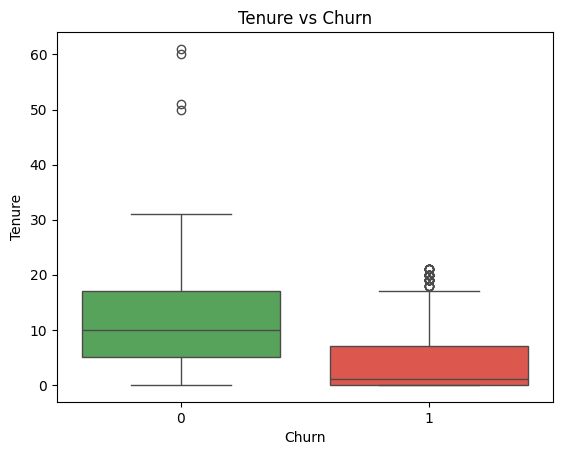

Churn
0    10.0
1     1.0
Name: Tenure, dtype: float64

In [85]:
sns.boxplot(x='Churn', y='Tenure', data=df, palette=['#4CAF50', '#F44336'])
plt.title("Tenure vs Churn")
plt.show()

df.groupby('Churn')['Tenure'].median()

**Explanation:** Terlihat adanya hubungan yang signifikan antara tenure dan churn, dengan churn lebih banyak terjadi pada pelanggan dengan tenure rendah.

### WarehouseToHome vs Churn

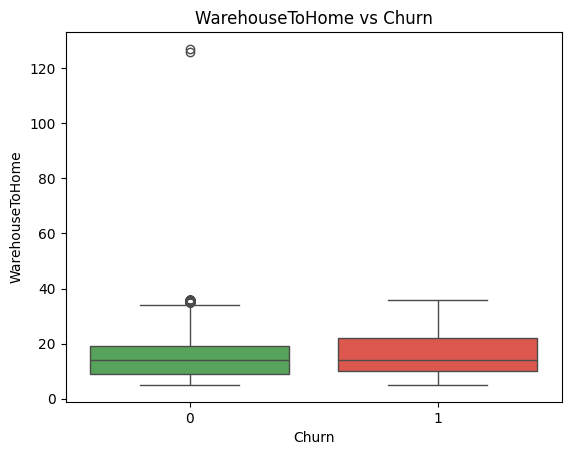

Churn
0    14.0
1    14.0
Name: WarehouseToHome, dtype: float64

In [86]:
sns.boxplot(x='Churn', y='WarehouseToHome', data=df, palette=['#4CAF50', '#F44336'])
plt.title("WarehouseToHome vs Churn")
plt.show()

df.groupby('Churn')['WarehouseToHome'].median()

In [87]:
# Pisahkan WarehouseToHome berdasarkan churn
wth_non_churn = df[df['Churn'] == 0]['WarehouseToHome']
wth_churn = df[df['Churn'] == 1]['WarehouseToHome']

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(
    wth_non_churn,
    wth_churn,
    alternative='two-sided'
)

print('U Statistic:', stat)
print('p-value:', p_value)

U Statistic: 1946192.5
p-value: 2.040863948002307e-09


**Explanation:** WarehouseToHome berhubungan signifikan dengan churn berdasarkan uji Mann–Whitney U (p-value < 0.05).

### HourSpendOnApp vs Churn

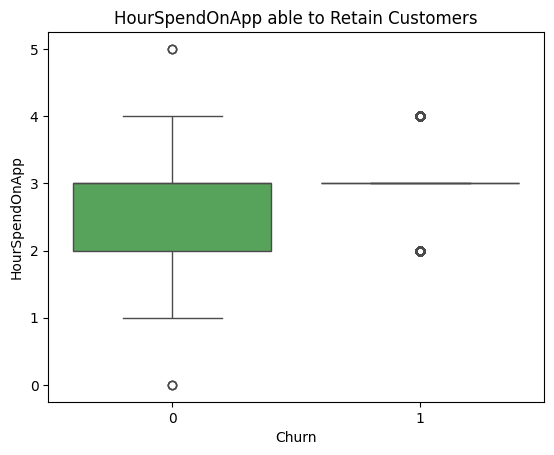

Churn
0    3.0
1    3.0
Name: HourSpendOnApp, dtype: float64

In [88]:
sns.boxplot(x='Churn', y='HourSpendOnApp', data=df, palette=['#4CAF50', '#F44336'])
plt.title("HourSpendOnApp able to Retain Customers")
plt.show()

df.groupby('Churn')['HourSpendOnApp'].median()

In [89]:
# Pisahkan HourSpendOnApp berdasarkan churn
wth_non_churn = df[df['Churn'] == 0]['HourSpendOnApp']
wth_churn = df[df['Churn'] == 1]['HourSpendOnApp']

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(
    wth_non_churn,
    wth_churn,
    alternative='two-sided'
)

print('U Statistic:', stat)
print('p-value:', p_value)

U Statistic: 2167074.0
p-value: 0.20945943456720229


**Explanation:** HourSpendOnApp tidak memiliki hubungan yang signifikan dengan churn berdasarkan uji Mann–Whitney U (p-value > 0.05).

### NumberOfDeviceRegistered vs Churn

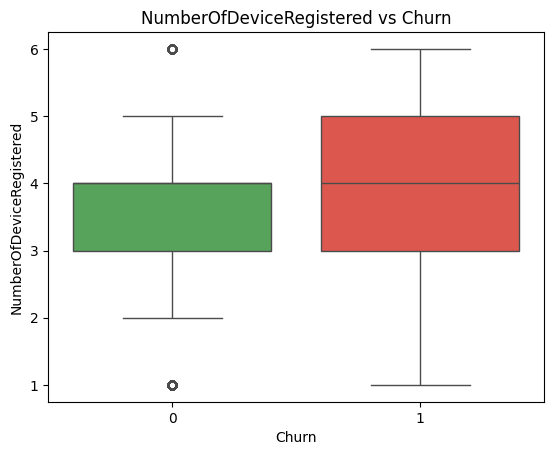

Churn
0    4.0
1    4.0
Name: NumberOfDeviceRegistered, dtype: float64

In [90]:
sns.boxplot(x='Churn', y='NumberOfDeviceRegistered', data=df, palette=['#4CAF50', '#F44336'])
plt.title("NumberOfDeviceRegistered vs Churn")
plt.show()

df.groupby('Churn')['NumberOfDeviceRegistered'].median()

In [91]:
# Pisahkan NumberOfDeviceRegistered berdasarkan churn
wth_non_churn = df[df['Churn'] == 0]['NumberOfDeviceRegistered']
wth_churn = df[df['Churn'] == 1]['NumberOfDeviceRegistered']

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(
    wth_non_churn,
    wth_churn,
    alternative='two-sided'
)

print('U Statistic:', stat)
print('p-value:', p_value)

U Statistic: 1891637.0
p-value: 3.054189123850868e-14


**Explanation:** NumberOfDeviceRegistered memiliki hubungan yang signifikan dengan churn (uji Mann–Whitney U, p-value < 0.05).

### SatisfactionScore vs Churn

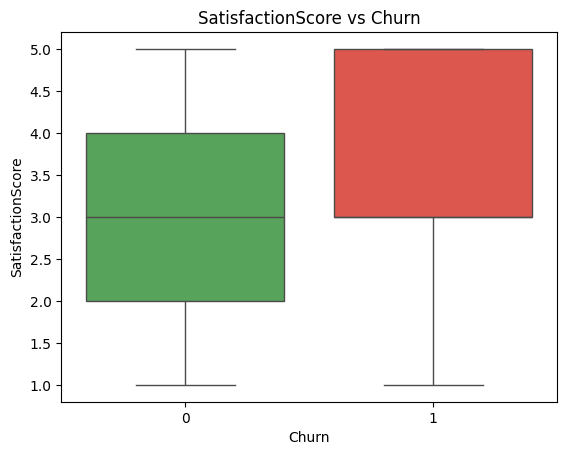

Churn
0    3.0
1    3.0
Name: SatisfactionScore, dtype: float64

In [92]:
sns.boxplot(x='Churn', y='SatisfactionScore', data=df, palette=['#4CAF50', '#F44336'])
plt.title("SatisfactionScore vs Churn")
plt.show()

df.groupby('Churn')['SatisfactionScore'].median()

**Explanation:** Terlihat adanya hubungan yang signifikan antara SatisfactionScore dan churn, dengan churn lebih banyak terjadi pada pelanggan dengan SatisfactionScore tinggi.

### NumberOfAddress vs Churn

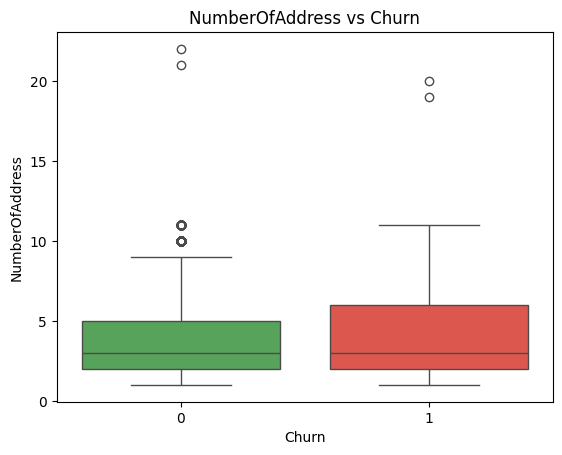

Churn
0    3.0
1    3.0
Name: NumberOfAddress, dtype: float64

In [93]:
sns.boxplot(x='Churn', y='NumberOfAddress', data=df, palette=['#4CAF50', '#F44336'])
plt.title("NumberOfAddress vs Churn")
plt.show()

df.groupby('Churn')['NumberOfAddress'].median()

In [94]:
# Pisahkan NumberOfAddress berdasarkan churn
wth_non_churn = df[df['Churn'] == 0]['NumberOfAddress']
wth_churn = df[df['Churn'] == 1]['NumberOfAddress']

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(
    wth_non_churn,
    wth_churn,
    alternative='two-sided'
)

print('U Statistic:', stat)
print('p-value:', p_value)

U Statistic: 2121979.5
p-value: 0.03049724563723119


**Explanation:** NumberOfAddress berhubungan signifikan dengan churn (uji Mann–Whitney U, p-value < 0.05)

### OrderAmountHikeFromlastYear vs Churn

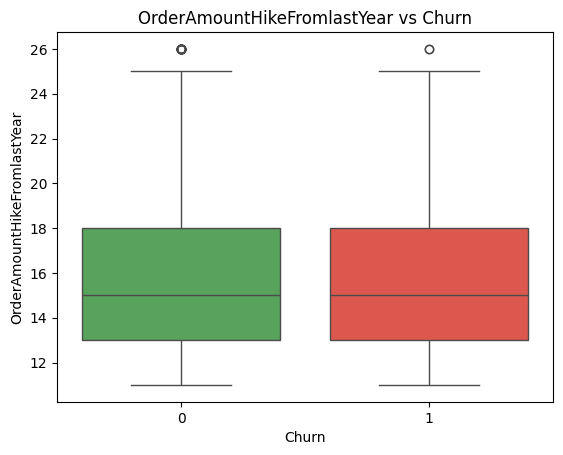

Churn
0    15.0
1    15.0
Name: OrderAmountHikeFromlastYear, dtype: float64

In [95]:
sns.boxplot(x='Churn', y='OrderAmountHikeFromlastYear', data=df, palette=['#4CAF50', '#F44336'])
plt.title("OrderAmountHikeFromlastYear vs Churn")
plt.show()

df.groupby('Churn')['OrderAmountHikeFromlastYear'].median()

In [96]:
# Pisahkan OrderAmountHikeFromlastYear berdasarkan churn
wth_non_churn = df[df['Churn'] == 0]['OrderAmountHikeFromlastYear']
wth_churn = df[df['Churn'] == 1]['OrderAmountHikeFromlastYear']

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(
    wth_non_churn,
    wth_churn,
    alternative='two-sided'
)

print('U Statistic:', stat)
print('p-value:', p_value)

U Statistic: 2292973.0
p-value: 0.1043907990290318


**Explanation:** Variabel tidak memiliki hubungan yang signifikan dengan churn (uji Mann–Whitney U, p-value > 0,05).

### CouponUsed vs Churn

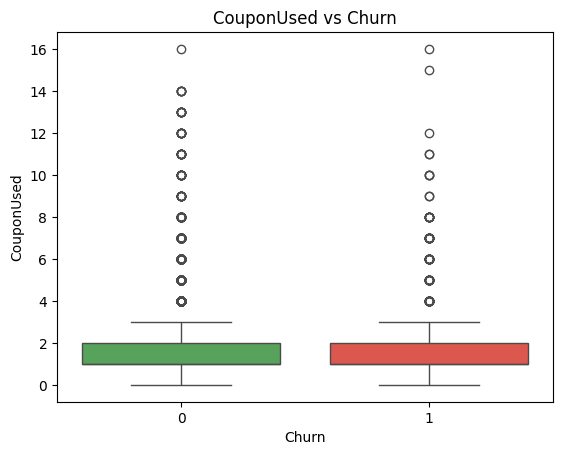

Churn
0    1.0
1    1.0
Name: CouponUsed, dtype: float64

In [97]:
sns.boxplot(x='Churn', y='CouponUsed', data=df, palette=['#4CAF50', '#F44336'])
plt.title("CouponUsed vs Churn")
plt.show()

df.groupby('Churn')['CouponUsed'].median()

In [98]:
# Pisahkan CouponUsed berdasarkan churn
wth_non_churn = df[df['Churn'] == 0]['CouponUsed']
wth_churn = df[df['Churn'] == 1]['CouponUsed']

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(
    wth_non_churn,
    wth_churn,
    alternative='two-sided'
)

print('U Statistic:', stat)
print('p-value:', p_value)

U Statistic: 2245721.5
p-value: 0.5430023781861197


**Explaination:** Variabel tidak memiliki hubungan yang signifikan dengan churn (uji Mann–Whitney U, p-value > 0.05).

### DaySinceLastOrder vs Churn

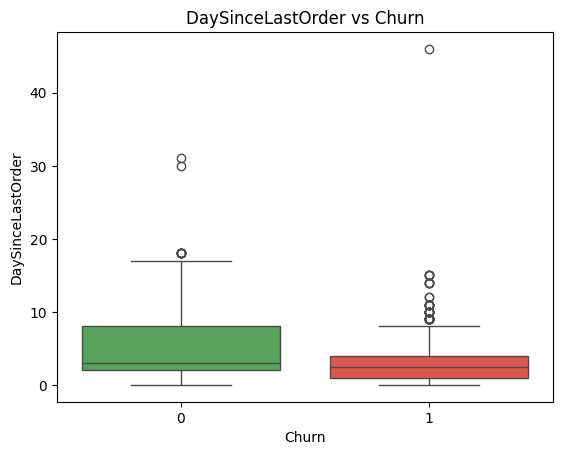

Churn
0    3.0
1    2.5
Name: DaySinceLastOrder, dtype: float64

In [99]:
sns.boxplot(x='Churn', y='DaySinceLastOrder', data=df, palette=['#4CAF50', '#F44336'])
plt.title("DaySinceLastOrder vs Churn")
plt.show()

df.groupby('Churn')['DaySinceLastOrder'].median()

**Explanation:** Terlihat adanya hubungan yang signifikan antara DaySinceLastOrder dan churn, dengan churn lebih banyak terjadi pada pelanggan dengan DaySinceLastOrder rendah.

### CashbackAmount vs Churn


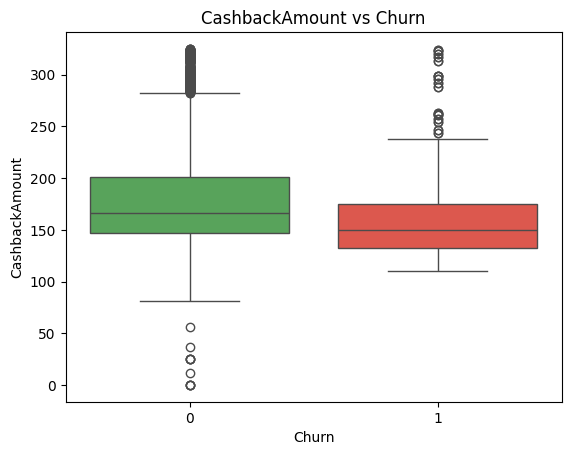

Churn
0    166.115
1    149.660
Name: CashbackAmount, dtype: float64

In [100]:
sns.boxplot(x='Churn', y='CashbackAmount', data=df, palette=['#4CAF50', '#F44336'])
plt.title("CashbackAmount vs Churn")
plt.show()

df.groupby('Churn')['CashbackAmount'].median()

**Explanation:** Terlihat adanya hubungan antara CashbackAmount dan churn, dengan churn lebih banyak terjadi pada pelanggan dengan CashbackAmount rendah.

## Bivariate Analysis - Kategorik

### Churn vs Gender

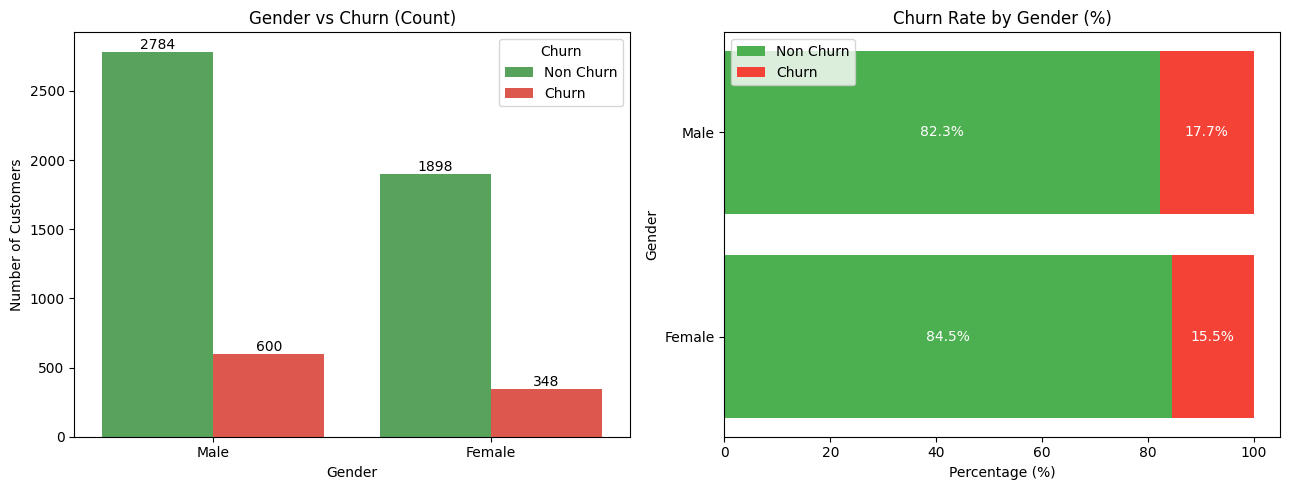

In [101]:
# Crosstab churn rate (%)
rate = pd.crosstab(df['Gender'], df['Churn'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# === KIRI: Countplot ===
palette = {0: '#4CAF50', 1: '#F44336'}
ax0 = axes[0]

sns.countplot(
    x='Gender',
    hue='Churn',
    data=df,
    palette=palette,
    ax=ax0,
    order=df['Gender'].value_counts().index
)

ax0.set_title('Gender vs Churn (Count)')
ax0.set_xlabel('Gender')
ax0.set_ylabel('Number of Customers')
ax0.legend(title='Churn', labels=['Non Churn', 'Churn'])

# Label count di atas bar
for container in ax0.containers:
    ax0.bar_label(container, fontsize=10)

# === KANAN: Horizontal Stacked Bar (Churn Rate %) ===
ax1 = axes[1]

ax1.barh(
    rate.index.astype(str),
    rate[0],
    color='#4CAF50',
    label='Non Churn'
)
ax1.barh(
    rate.index.astype(str),
    rate[1],
    left=rate[0],
    color='#F44336',
    label='Churn'
)

ax1.set_title('Churn Rate by Gender (%)')
ax1.set_xlabel('Percentage (%)')
ax1.set_ylabel('Gender')
ax1.legend()

# Label persentase
for i in range(len(rate)):
    ax1.text(rate.iloc[i, 0] / 2, i,
             f"{rate.iloc[i, 0]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)
    ax1.text(rate.iloc[i, 0] + rate.iloc[i, 1] / 2, i,
             f"{rate.iloc[i, 1]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()


**Explanation:**

Berdasarkan hasil analisis, jumlah absolut jumlah churn pada pelanggan laki-laki juga lebih tinggi dibandingkan perempuan. Secara proporsi, pelanggan laki-laki memiliki churn rate lebih tinggi dibandingkan pelanggan perempuan.

### Churn vs Marital Status

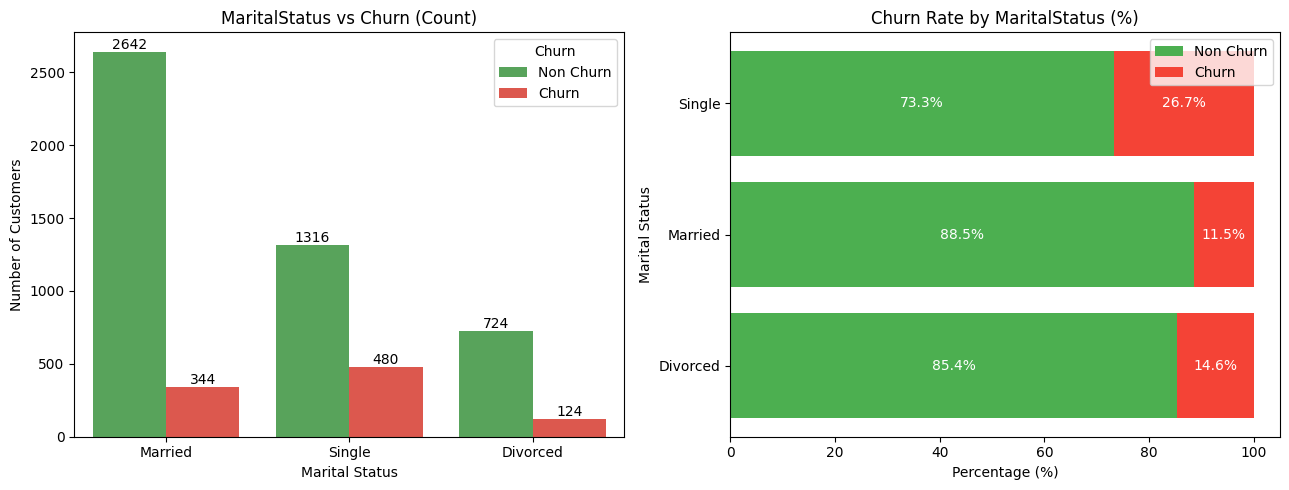

In [102]:
# Crosstab churn rate (%)
rate = pd.crosstab(df['MaritalStatus'], df['Churn'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# === KIRI: Countplot ===
palette = {0: '#4CAF50', 1: '#F44336'}
ax0 = axes[0]

sns.countplot(
    x='MaritalStatus',
    hue='Churn',
    data=df,
    palette=palette,
    ax=ax0,
    order=df['MaritalStatus'].value_counts().index
)

ax0.set_title('MaritalStatus vs Churn (Count)')
ax0.set_xlabel('Marital Status')
ax0.set_ylabel('Number of Customers')
ax0.legend(title='Churn', labels=['Non Churn', 'Churn'])

# Label count di atas bar
for container in ax0.containers:
    ax0.bar_label(container, fontsize=10)

# === KANAN: Horizontal Stacked Bar (Churn Rate %) ===
ax1 = axes[1]

ax1.barh(
    rate.index.astype(str),
    rate[0],
    color='#4CAF50',
    label='Non Churn'
)
ax1.barh(
    rate.index.astype(str),
    rate[1],
    left=rate[0],
    color='#F44336',
    label='Churn'
)

ax1.set_title('Churn Rate by MaritalStatus (%)')
ax1.set_xlabel('Percentage (%)')
ax1.set_ylabel('Marital Status')
ax1.legend()

# Label persentase
for i in range(len(rate)):
    ax1.text(rate.iloc[i, 0] / 2, i,
             f"{rate.iloc[i, 0]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)
    ax1.text(rate.iloc[i, 0] + rate.iloc[i, 1] / 2, i,
             f"{rate.iloc[i, 1]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()


**Explanation:**

Pelanggan dengan status Single cenderung memiliki risiko churn yang lebih tinggi dibandingkan pelanggan yang sudah menikah maupun bercerai.

### Churn vs City Tier

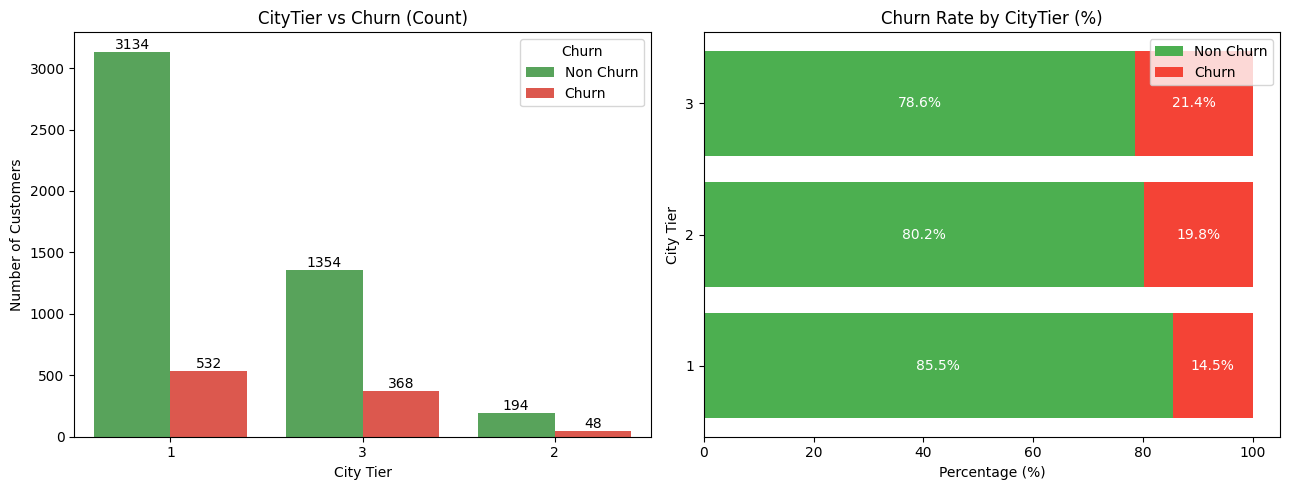

In [103]:
# Crosstab churn rate (%)
rate = pd.crosstab(df['CityTier'], df['Churn'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# === KIRI: Countplot ===
palette = {0: '#4CAF50', 1: '#F44336'}
ax0 = axes[0]

sns.countplot(
    x='CityTier',
    hue='Churn',
    data=df,
    palette=palette,
    ax=ax0,
    order=df['CityTier'].value_counts().index
)

ax0.set_title('CityTier vs Churn (Count)')
ax0.set_xlabel('City Tier')
ax0.set_ylabel('Number of Customers')
ax0.legend(title='Churn', labels=['Non Churn', 'Churn'])

# 👉 Tambah label count di atas bar
for container in ax0.containers:
    ax0.bar_label(container, fontsize=10)

# === KANAN: Horizontal Stacked Bar (Churn Rate %) ===
ax1 = axes[1]

ax1.barh(
    rate.index.astype(str),
    rate[0],
    color='#4CAF50',
    label='Non Churn'
)
ax1.barh(
    rate.index.astype(str),
    rate[1],
    left=rate[0],
    color='#F44336',
    label='Churn'
)

ax1.set_title('Churn Rate by CityTier (%)')
ax1.set_xlabel('Percentage (%)')
ax1.set_ylabel('City Tier')
ax1.legend()

# Label persentase
for i in range(len(rate)):
    ax1.text(rate.iloc[i, 0] / 2, i,
             f"{rate.iloc[i, 0]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)
    ax1.text(rate.iloc[i, 0] + rate.iloc[i, 1] / 2, i,
             f"{rate.iloc[i, 1]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()


**Explanation:**

CityTier 3 memiliki risiko churn relatif lebih tinggi. Bisa dikarenakan karena perbedaan infrastruktur dan fasilitas yang ada pada daerah tersebut.

### Churn vs Preferred Login Device

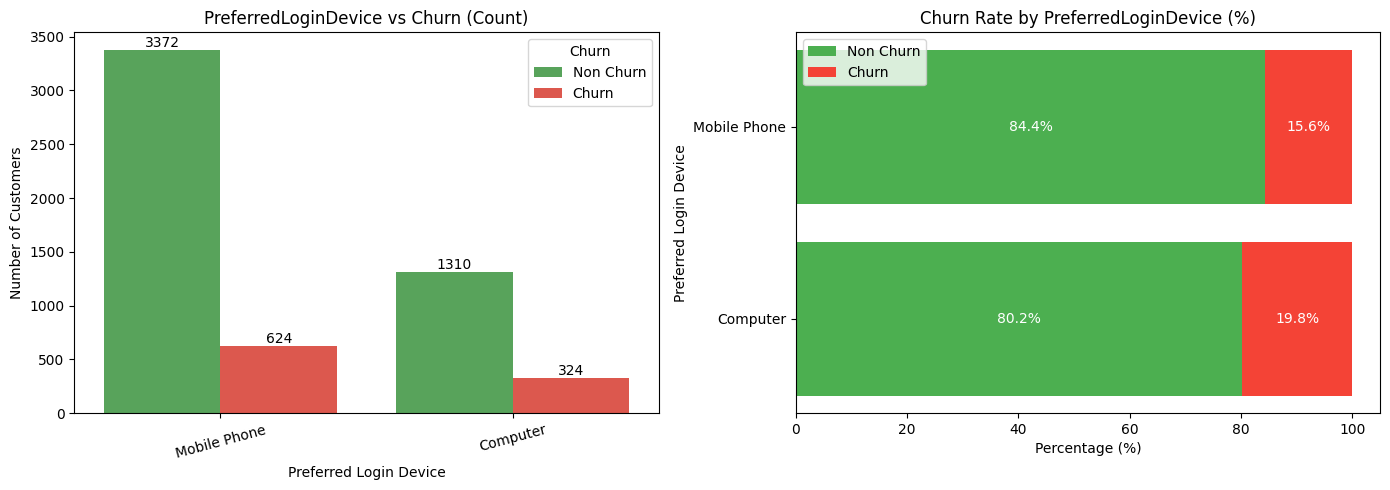

In [104]:
# Crosstab churn rate (%)
rate = pd.crosstab(df['PreferredLoginDevice'], df['Churn'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === KIRI: Countplot ===
palette = {0: '#4CAF50', 1: '#F44336'}
ax0 = axes[0]

sns.countplot(
    x='PreferredLoginDevice',
    hue='Churn',
    data=df,
    palette=palette,
    ax=ax0
)

ax0.set_title('PreferredLoginDevice vs Churn (Count)')
ax0.set_xlabel('Preferred Login Device')
ax0.set_ylabel('Number of Customers')
ax0.legend(title='Churn', labels=['Non Churn', 'Churn'])

# Putar label biar kebaca
ax0.tick_params(axis='x', rotation=15)

# Label count di atas bar
for container in ax0.containers:
    ax0.bar_label(container, fontsize=10)

# === KANAN: Horizontal Stacked Bar (Churn Rate %) ===
ax1 = axes[1]

ax1.barh(
    rate.index.astype(str),
    rate[0],
    color='#4CAF50',
    label='Non Churn'
)
ax1.barh(
    rate.index.astype(str),
    rate[1],
    left=rate[0],
    color='#F44336',
    label='Churn'
)

ax1.set_title('Churn Rate by PreferredLoginDevice (%)')
ax1.set_xlabel('Percentage (%)')
ax1.set_ylabel('Preferred Login Device')
ax1.legend()

# Label persentase
for i in range(len(rate)):
    ax1.text(rate.iloc[i, 0] / 2, i,
             f"{rate.iloc[i, 0]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)
    ax1.text(rate.iloc[i, 0] + rate.iloc[i, 1] / 2, i,
             f"{rate.iloc[i, 1]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()


**Explanation:**

Hal ini menunjukkan bahwa meskipun mayoritas pelanggan mengakses layanan melalui perangkat mobile. Risiko churn relatif lebih tinggi pada pelanggan yang menggunakan komputer sebagai perangkat login utama.

### Churn vs Payment Method

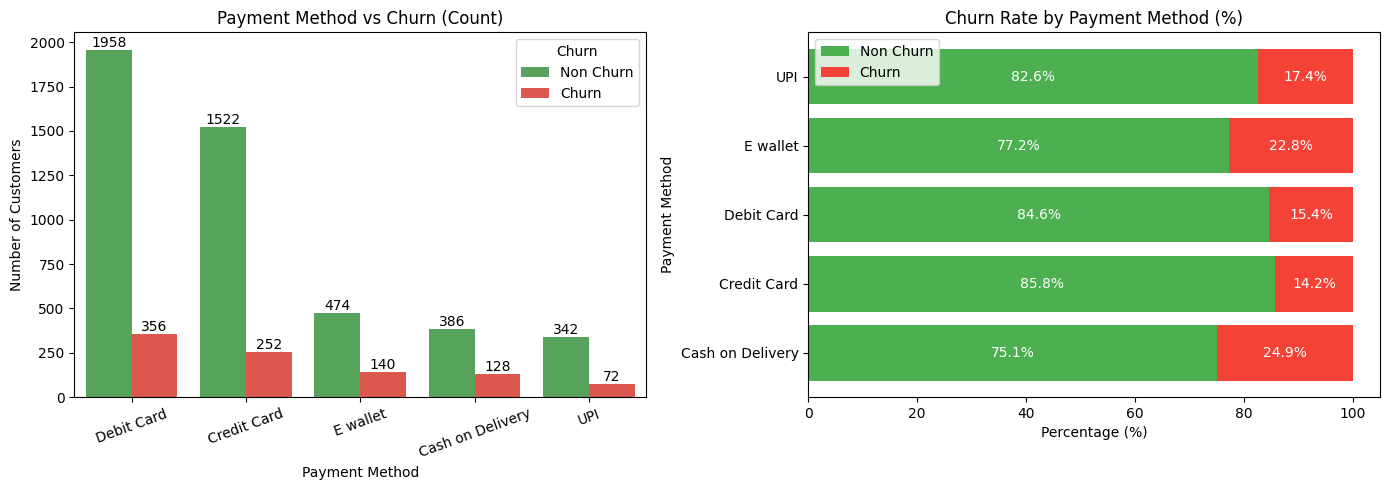

In [105]:
# Crosstab churn rate (%)
rate = pd.crosstab(df['PreferredPaymentMode'], df['Churn'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === KIRI: Countplot ===
palette = {0: '#4CAF50', 1: '#F44336'}
ax0 = axes[0]

sns.countplot(
    x='PreferredPaymentMode',
    hue='Churn',
    data=df,
    palette=palette,
    ax=ax0,
    order=df['PreferredPaymentMode'].value_counts().index
)

ax0.set_title('Payment Method vs Churn (Count)')
ax0.set_xlabel('Payment Method')
ax0.set_ylabel('Number of Customers')
ax0.legend(title='Churn', labels=['Non Churn', 'Churn'])

# Putar label biar kebaca
ax0.tick_params(axis='x', rotation=20)

# Label count di atas bar
for container in ax0.containers:
    ax0.bar_label(container, fontsize=10)

# === KANAN: Horizontal Stacked Bar (Churn Rate %) ===
ax1 = axes[1]

ax1.barh(
    rate.index.astype(str),
    rate[0],
    color='#4CAF50',
    label='Non Churn'
)
ax1.barh(
    rate.index.astype(str),
    rate[1],
    left=rate[0],
    color='#F44336',
    label='Churn'
)

ax1.set_title('Churn Rate by Payment Method (%)')
ax1.set_xlabel('Percentage (%)')
ax1.set_ylabel('Payment Method')
ax1.legend()

# Label persentase
for i in range(len(rate)):
    ax1.text(rate.iloc[i, 0] / 2, i,
             f"{rate.iloc[i, 0]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)
    ax1.text(rate.iloc[i, 0] + rate.iloc[i, 1] / 2, i,
             f"{rate.iloc[i, 1]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()


**Explanation:**

Pelanggan yang menggunakan metode pembayaran non-kartu cenderung memiliki risiko churn yang lebih tinggi dibandingkan pengguna kartu pembayaran.

### Churn vs Complain

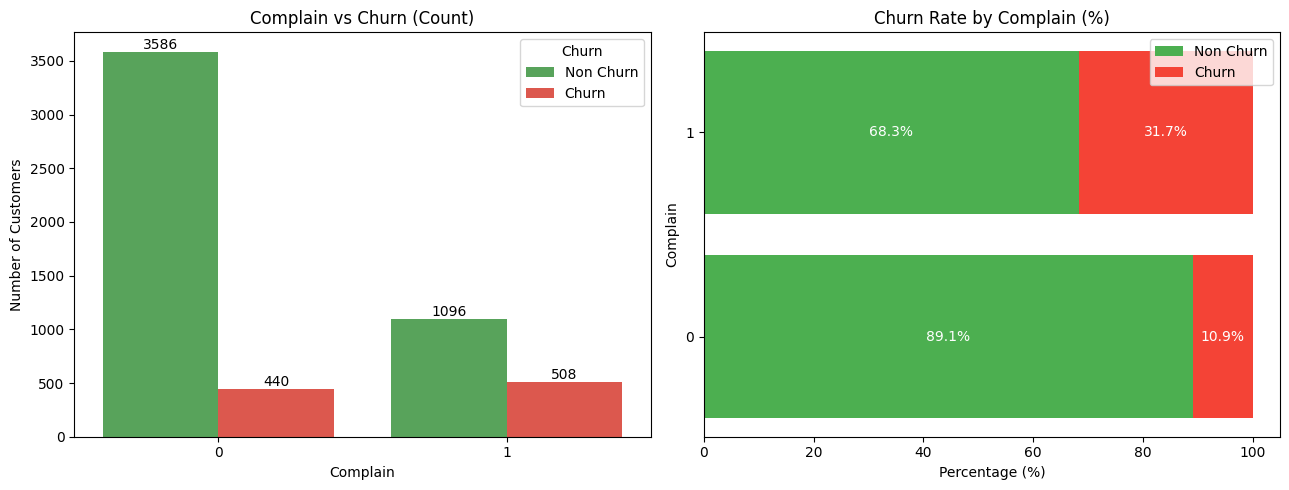

In [106]:
# Crosstab churn rate (%)
rate = pd.crosstab(df['Complain'], df['Churn'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# === KIRI: Countplot ===
palette = {0: '#4CAF50', 1: '#F44336'}
ax0 = axes[0]

sns.countplot(
    x='Complain',
    hue='Churn',
    data=df,
    palette=palette,
    ax=ax0,
    order = df['Complain'].value_counts().index
)

ax0.set_title('Complain vs Churn (Count)')
ax0.set_xlabel('Complain')
ax0.set_ylabel('Number of Customers')
ax0.legend(title='Churn', labels=['Non Churn', 'Churn'])

# Label count di atas bar
for container in ax0.containers:
    ax0.bar_label(container, fontsize=10)

# === KANAN: Horizontal Stacked Bar (Churn Rate %) ===
ax1 = axes[1]

ax1.barh(
    rate.index.astype(str),
    rate[0],
    color='#4CAF50',
    label='Non Churn'
)
ax1.barh(
    rate.index.astype(str),
    rate[1],
    left=rate[0],
    color='#F44336',
    label='Churn'
)

ax1.set_title('Churn Rate by Complain (%)')
ax1.set_xlabel('Percentage (%)')
ax1.set_ylabel('Complain')
ax1.legend()

# Label persentase
for i in range(len(rate)):
    ax1.text(rate.iloc[i, 0] / 2, i,
             f"{rate.iloc[i, 0]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)
    ax1.text(rate.iloc[i, 0] + rate.iloc[i, 1] / 2, i,
             f"{rate.iloc[i, 1]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()


**Explanation:**

Meskipun secara jumlah pelanggan tanpa komplain lebih besar, proporsi churn jauh lebih tinggi pada pelanggan yang pernah komplain, mengindikasikan bahwa komplain merupakan early warning signal churn dan menjadi variabel penting retensi pelanggan.

### Churn vs OrderCategory

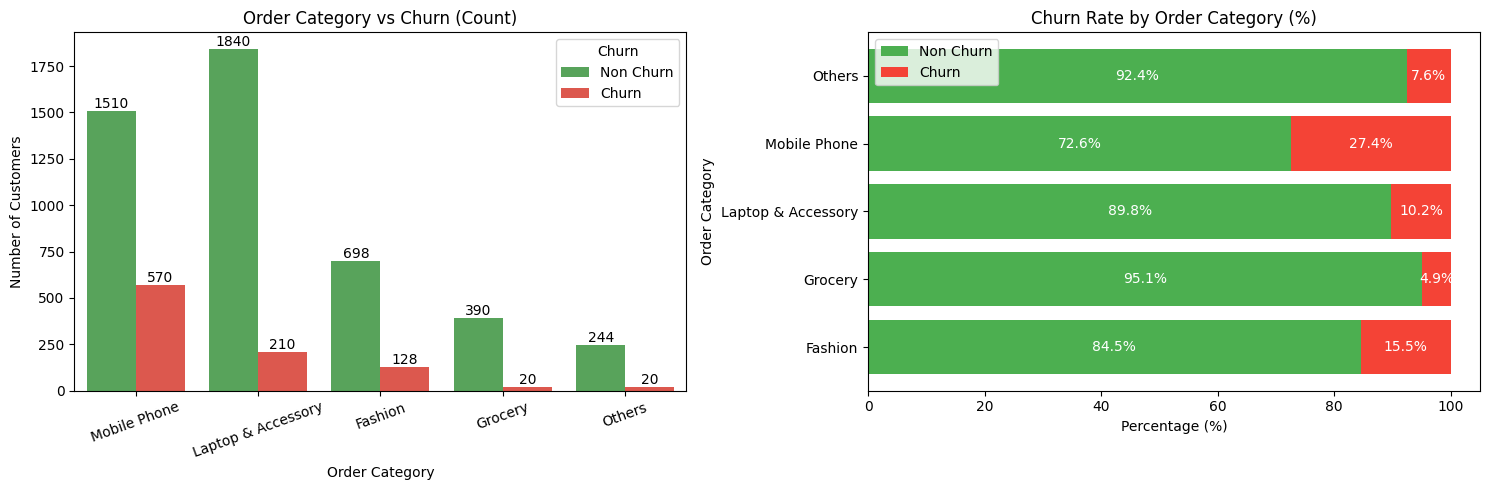

In [107]:
# Crosstab churn rate (%)
rate = pd.crosstab(df['PreferedOrderCat'], df['Churn'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# === KIRI: Countplot ===
palette = {0: '#4CAF50', 1: '#F44336'}
ax0 = axes[0]

sns.countplot(
    x='PreferedOrderCat',
    hue='Churn',
    data=df,
    palette=palette,
    ax=ax0,
    order = df['PreferedOrderCat'].value_counts().index
)

ax0.set_title('Order Category vs Churn (Count)')
ax0.set_xlabel('Order Category')
ax0.set_ylabel('Number of Customers')
ax0.legend(title='Churn', labels=['Non Churn', 'Churn'])

# Putar label biar kebaca
ax0.tick_params(axis='x', rotation=20)

# Label count di atas bar
for container in ax0.containers:
    ax0.bar_label(container, fontsize=10)

# === KANAN: Horizontal Stacked Bar (Churn Rate %) ===
ax1 = axes[1]

ax1.barh(
    rate.index.astype(str),
    rate[0],
    color='#4CAF50',
    label='Non Churn'
)
ax1.barh(
    rate.index.astype(str),
    rate[1],
    left=rate[0],
    color='#F44336',
    label='Churn'
)

ax1.set_title('Churn Rate by Order Category (%)')
ax1.set_xlabel('Percentage (%)')
ax1.set_ylabel('Order Category')
ax1.legend()

# Label persentase
for i in range(len(rate)):
    ax1.text(rate.iloc[i, 0] / 2, i,
             f"{rate.iloc[i, 0]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)
    ax1.text(rate.iloc[i, 0] + rate.iloc[i, 1] / 2, i,
             f"{rate.iloc[i, 1]:.1f}%",
             va='center', ha='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()

In [108]:
# Periksa Ulang Missing Value
df.isnull().sum()

Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [109]:
df.to_csv("EcommerceChurnCleaned.csv", index=False)

In [110]:
import os
print(os.getcwd())

c:\Users\Medina Alifia\OneDrive\Documents\Purwadhika\Python for DA\Final Project


## **Train Test Split**
---

In [111]:
# Split data (train / test)

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (4504, 18) Test: (1126, 18)


**Explanation:** Data di split menjadi 80% dan 20% 

## **Preprocessing**
---

In [112]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object','category']).columns

cat_features_idx = [
    X_train.columns.get_loc(col)
    for col in cat_cols
]

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


## **Model Benchmarking**
---

In [113]:
# F2 scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

# Stratified CV (important for churn imbalance)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

**Keterangan:**
- F2 score adalah metrik evaluasi untuk model klasifikasi, turunan dari F-score, yang memberi bobot lebih besar pada Recall dibanding Precision.

- Secara intuitif:
F2 score cocok ketika “kehilangan kasus positif” (**FN**) jauh lebih berbahaya daripada “false alarm” (**FP**).

In [114]:
# Define Model

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
lgbm = LGBMClassifier(random_state=42)
svm = SVC(random_state=42, 
            probability=True,           
            class_weight='balanced')

models = [logreg,knn,dt,rf,xgb,lgbm,svm]

results = []

for name, model in zip(models, models):
    
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=f2_scorer,
        n_jobs=-1
    )
    
    results.append({
        'Model': name,
        'Mean F2 Score': scores.mean(),
        'Std F2 Score': scores.std()
    })

benchmark_f2 = (
    pd.DataFrame(results)
    .sort_values(by='Mean F2 Score', ascending=False)
)

benchmark_f2

,Model,Mean F2 Score,Std F2 Score
4,"XGBClassifier(base_score=None, booster=None, c...",0.836279,0.028404
5,LGBMClassifier(random_state=42),0.820183,0.016453
6,"SVC(class_weight='balanced', probability=True,...",0.800749,0.006648
2,DecisionTreeClassifier(class_weight='balanced'...,0.779330,0.030063
3,RandomForestClassifier(class_weight='balanced'...,0.768593,0.044863
0,"LogisticRegression(class_weight='balanced', ma...",0.703579,0.033404
1,KNeighborsClassifier(),0.600395,0.033611


## **Data Check**

In [115]:
# Data Check (Imbalance)
counts = df['Churn'].value_counts()

# hitung persentase
percentages = df['Churn'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'count': counts,
    'percentage (%)': percentages.round(2)
})

print(imbalance_df)

       count  percentage (%)
Churn                       
0       4682           83.16
1        948           16.84


**Explanation:** Data terbukti imbalance sehingga membutuhkan over sampling. 

- SMOTENC adalah teknik oversampling untuk data imbalanced yang punya fitur numerik DAN kategorikal.
- SMOTENC digunakan jika:
    1. Fokus menekan False Negative
    2. Metrik utama: Recall / F2
    3. Ada business cost besar jika miss positive
    
    Contoh kasus churn:
    
    Lebih baik salah follow-up daripada kehilangan pelanggan

## **Model Benchmarking + SMOTENC**

In [116]:
results = []

for name, model in zip(models, models):

    pipeline = Pipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=cat_features_idx,
            sampling_strategy='auto',
            random_state=42
        )),
        ('preprocess', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=f2_scorer,
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'Mean F2 Score': scores.mean(),
        'Std F2 Score': scores.std()
    })

benchmark_f2_smote = (
    pd.DataFrame(results)
    .sort_values(by='Mean F2 Score', ascending=False)
)

benchmark_f2_smote

,Model,Mean F2 Score,Std F2 Score
4,"XGBClassifier(base_score=None, booster=None, c...",0.849508,0.019913
3,RandomForestClassifier(class_weight='balanced'...,0.827046,0.030934
5,LGBMClassifier(random_state=42),0.809290,0.025934
1,KNeighborsClassifier(),0.792395,0.015988
2,DecisionTreeClassifier(class_weight='balanced'...,0.767518,0.042180
6,"SVC(class_weight='balanced', probability=True,...",0.756605,0.014123
0,"LogisticRegression(class_weight='balanced', ma...",0.683898,0.019922


**Explanation:** Setelah dilakukan uji dengan SMOTENC untuk semua model, hasil tetap menunjukkan XGBoost menjadi model evaluasi paling baik. 

## **Hyperparameter Tuning & Model Evaluation**

In [117]:
f2_scorer = make_scorer(fbeta_score, beta=2)

skfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_xgb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

In [159]:
param_grid_xgb = {
    'model__n_estimators': [200, 300, 400],
    'model__max_depth': [3, 4],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__min_child_weight': [1, 5, 7]
}

grid_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

best_model_xgb = grid_xgb.best_estimator_

# Train predictions and scores
y_train_pred = best_model_xgb.predict(X_train)
train_f2 = fbeta_score(y_train, y_train_pred, beta=2)
print("Train F2 Score   :", round(train_f2, 4))
print("Train Classification Report:")
print(classification_report(y_train, y_train_pred))

# Test predictions and scores
y_pred = best_model_xgb.predict(X_test)
test_f2 = fbeta_score(y_test, y_pred, beta=2)
print("Test F2 Score    :", round(test_f2, 4))
print("Test Classification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Train F2 Score   : 0.9828
Train Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3746
           1       0.99      0.98      0.99       758

    accuracy                           1.00      4504
   macro avg       0.99      0.99      0.99      4504
weighted avg       1.00      1.00      1.00      4504

Test F2 Score    : 0.9076
Test Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       936
           1       0.94      0.90      0.92       190

    accuracy                           0.97      1126
   macro avg       0.96      0.94      0.95      1126
weighted avg       0.97      0.97      0.97      1126



**Explanation:** Hasil setelah tuning menunjukkan model F2 Score (Train) sebesar 98% dan Test F2 Score sebesar 90%.

## **Cost Benefit Analysis**

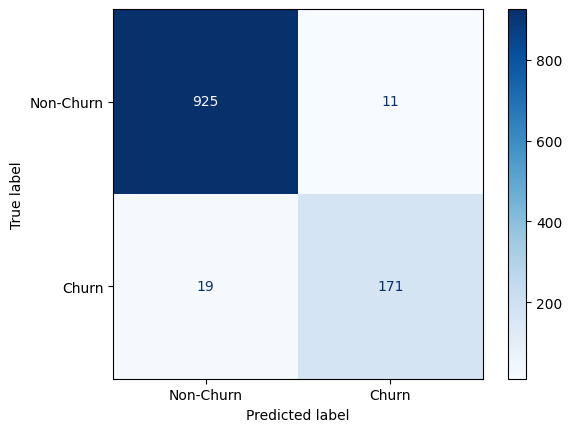

In [147]:
# Confusion Matrix Analysis

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Churn', 'Churn']
).plot(cmap='Blues')

In [148]:
# Ambil nilai confusion matrix
# Format cm:
# [[True Negative, False Positive],
#  [False Negative, True Positive]]

tn, fp, fn, tp = cm.ravel()

# Jumlah kondisi aktual di data uji
real_loyal = tn + fp
real_churn = fn + tp

print("Ringkasan Data Uji (1126 Pelanggan atau 20% dari Dataset)")
print(f"Jumlah pelanggan loyal sebenarnya : {real_loyal}")
print(f"Jumlah pelanggan churn sebenarnya : {real_churn}")
print("-" * 80)

print("Ringkasan Prediksi Model")
print(f"True Negative  (TN): {tn} → Loyal diprediksi loyal")
print(f"False Positive (FP): {fp} → Loyal diprediksi churn (biaya promo sia-sia)")
print(f"False Negative (FN): {fn} → Churn diprediksi loyal (kehilangan pelanggan)")
print(f"True Positive  (TP): {tp} → Churn diprediksi churn (berhasil dicegah)")


Ringkasan Data Uji (1126 Pelanggan atau 20% dari Dataset)
Jumlah pelanggan loyal sebenarnya : 936
Jumlah pelanggan churn sebenarnya : 190
--------------------------------------------------------------------------------
Ringkasan Prediksi Model
True Negative  (TN): 925 → Loyal diprediksi loyal
False Positive (FP): 11 → Loyal diprediksi churn (biaya promo sia-sia)
False Negative (FN): 19 → Churn diprediksi loyal (kehilangan pelanggan)
True Positive  (TP): 171 → Churn diprediksi churn (berhasil dicegah)


**Explanation:** Karena menggunakan F2 Score, perbandingan FP dan FN adalah 1 : 4 sehingga biaya yang dikeluarkan FN lebih besar 4x dari FP.

In [149]:
# Asumsi Pengeluaran Per Bulan

cost_fn = 450_000   # kerugian kehilangan 1 pelanggan dalam satu bulan
cost_fp = 112_500    # estimasi biaya promo/intervensi yang dikeluarkan (bisa dalam bentuk kupon / cashback)

**Explanation:** Berdasarkan (https://data.goodstats.id/statistic/berapa-rupiah-dihabiskan-masyarakat-ri-saat-belanja-online-B20QI#goog_rewarded) masyarakat Indonesia bisa menghabiskan sekitar Rp450.000 setiap bulannya untuk berbelanja online. 

## **Prediksi Tanpa Model ML**

In [150]:
# Skenario Tanpa Model ML (Loss FP) - Pesimis (Semua ditebak Churn)

loss_without_model1 = real_loyal * cost_fp

print("Skenario Tanpa Model 1")
print(f"{real_loyal} pelanggan churn × Rp {cost_fp:,}")
print(f"Total kerugian: Rp {loss_without_model1:,}")

Skenario Tanpa Model 1
936 pelanggan churn × Rp 112,500
Total kerugian: Rp 105,300,000


In [151]:
# Skenario Tanpa Model ML (Loss FN) - Optimis (Semua ditebak No Churn)

loss_without_model2 = real_churn * cost_fn

print("Skenario Tanpa Model 2")
print(f"{real_churn} pelanggan churn × Rp {cost_fn:,}")
print(f"Total kerugian: Rp {loss_without_model2:,}")

Skenario Tanpa Model 2
190 pelanggan churn × Rp 450,000
Total kerugian: Rp 85,500,000


## **Prediksi dengan Model ML**

In [153]:
# Skenario dengan Model ML 

loss_with_model = (fn * cost_fn) + ((fp) * cost_fp)

print("\nSkenario Menggunakan Model")
print(f"Kerugian akibat (FN) : {fn} × Rp {cost_fn:,}")
print(f"Biaya salah intervensi (FP)  : {(fp)} × Rp {cost_fp:,}")
print(f"Total biaya: Rp {loss_with_model:,}")



Skenario Menggunakan Model
Kerugian akibat (FN) : 19 × Rp 450,000
Biaya salah intervensi (FP)  : 11 × Rp 112,500
Total biaya: Rp 9,787,500


## **Total Saving (Biaya Penghematan)**

In [154]:
# Penghematan Model 1 (Skenario 1)
savings1 = loss_without_model1 - loss_with_model

print("\n" + "=" * 45)
print("RINGKASAN ANALISIS COST–BENEFIT")
print("=" * 45)
print(f"Kerugian tanpa model : Rp {loss_without_model1:,}")
print(f"Biaya dengan model   : Rp {loss_with_model:,}")
print("-" * 45)
print(f"Penghematan bersih   : Rp {savings1:,}")
print("=" * 45)



RINGKASAN ANALISIS COST–BENEFIT
Kerugian tanpa model : Rp 105,300,000
Biaya dengan model   : Rp 9,787,500
---------------------------------------------
Penghematan bersih   : Rp 95,512,500


In [155]:
# Biaya Intervensi Model Skenario 1

intervention_cost = 1126 * cost_fp
roi = (savings1 / intervention_cost) * 100

print(f"\nTotal biaya intervensi: Rp {intervention_cost:,}")
print(f"ROI model churn: {roi:.2f}%")



Total biaya intervensi: Rp 126,675,000
ROI model churn: 75.40%


In [156]:
# Penghematan Model 2
savings2 = loss_without_model2 - loss_with_model

print("\n" + "=" * 45)
print("RINGKASAN ANALISIS COST–BENEFIT")
print("=" * 45)
print(f"Kerugian tanpa model : Rp {loss_without_model2:,}")
print(f"Biaya dengan model   : Rp {loss_with_model:,}")
print("-" * 45)
print(f"Penghematan bersih   : Rp {savings2:,}")
print("=" * 45)



RINGKASAN ANALISIS COST–BENEFIT
Kerugian tanpa model : Rp 85,500,000
Biaya dengan model   : Rp 9,787,500
---------------------------------------------
Penghematan bersih   : Rp 75,712,500


In [158]:
# Biaya Intervensi Model Skenario 2

intervention_cost = 0 * cost_fp
roi = (savings2 / intervention_cost) * 100

print(f"\nTotal biaya intervensi: Rp {intervention_cost:,}")
print(f"ROI model churn: - ")


Total biaya intervensi: Rp 0
ROI model churn: - 


## **Analisis Kesimpulan dan Rekomendasi Bisnis**



Berdasarkan analisis end-to-end menggunakan dataset E-Commerce Churn dan model XGBoost (F2-Score Optimized), berikut adalah strategi untuk menekan angka churn sebesar **16,84%**.

### Kesimpulan Utama

**Masa Kritis (Tenure Pendek)**
Churn didominasi oleh pelanggan dengan masa langganan rendah. Ini adalah indikasi kuat adanya masalah pada fase onboarding atau ekspektasi yang tidak terpenuhi di awal penggunaan layanan.

**Pemicu Fatal (Complain)**
Variabel **Complain** adalah prediktor yang sangat akurat. Pelanggan yang pernah menyampaikan komplain cenderung langsung churn jika tidak ditangani dengan luar biasa baik.

**Profil Demografis Rentan**
Churn paling banyak terjadi pada pelanggan **Laki-laki (Male)** dan berstatus **Single**. Kelompok ini cenderung memiliki loyalitas yang lebih rendah dan lebih cepat bereaksi terhadap ketidakpuasan.

**Faktor Geografis & Perilaku**
Pelanggan di **City Tier 3** dan mereka yang memiliki **Day Since Last Order** rendah (baru saja belanja) merupakan segmen yang paling labil.

### **Akurasi Model**
Model XGBoost berhasil mengidentifikasi **171 dari 190 pelanggan churn aktual**. Dengan fokus pada **F2-Score**, kita berhasil meminimalisir risiko "kecolongan" pelanggan (hanya 19 False Negative) dengan biaya operasional yang sangat efisien (hanya 11 False Positive).

| Metrik               | Skenario 1: Tanpa Model (Pesimis) | Skenario 2: Tanpa Model (Optimis) | Skenario 3: Dengan Model ML (Proaktif)      |
|----------------------|-----------------------------------|-----------------------------------|---------------------------------------------|
| Kerugian Churn (FN)  | Rp 0                             | Rp 85.500.000 (190 Churner)       | Rp 8.550.000 (Hanya 19 Churner)              |
| Biaya Promo (FP)     | Rp 105.300.000                   | Rp 0                             | Rp 1.237.500 (Hanya 11 Salah Target)           |
| Total Biaya & Kerugian| Rp 105.300.000                  | Rp 85.500.000                    | RRp 9.787.500                                |

### **Rekomendasi**

- Untuk menekan angka churn, perusahaan perlu menjalankan program **"First 3 Months Onboarding atau Life Cycle Strategy"** guna menjaga pelanggan di masa kritis mereka. Dengan memberikan early warning dan reward bertahap seperti kupon gratis ongkir di bulan kedua dan ketiga, perusahaan dapat membangun kebiasaan belanja (habit) pada pelanggan baru. Selain itu, diperlukan **"Jalur Cepat Penanganan Komplain"** melalui sistem Red Flag untuk keluhan dari pelanggan. Tim Customer Service wajib memberikan resolusi dalam kurang dari 24 jam disertai kompensasi otomatis untuk meredam niat churn.
Terakhir, perusahaan harus melakukan **"Optimasi Logistik & Personalisasi Segmen"**, khususnya di City Tier 3, dengan memperbaiki kecepatan pengiriman atau memberikan promo yang lebih relevan bagi profil yang cenderung churn. (Dalam konteks ini, pada City Tier 3 di dominasi oleh pria berstatus single).

## Features Importance & SHAP Analysis 
---

In [129]:
# ambil preprocessor & model
preprocessor = best_model_xgb.named_steps['preprocess']
model = best_model_xgb.named_steps['model']

# fungsi helper untuk ambil nama fitur
def get_feature_names(preprocessor):
    feature_names = []

    for name, transformer, cols in preprocessor.transformers_:
        if transformer == 'drop':
            continue

        if hasattr(transformer, 'get_feature_names_out'):
            names = transformer.get_feature_names_out(cols)
        else:
            names = cols

        feature_names.extend(names)

    return feature_names

feature_names = get_feature_names(preprocessor)

In [130]:
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)


,feature,importance
0,Tenure,0.107728
31,Complain_0,0.081751
26,PreferedOrderCat_Mobile Phone,0.060358
24,PreferedOrderCat_Grocery,0.053517
25,PreferedOrderCat_Laptop & Accessory,0.042278
30,MaritalStatus_Single,0.040172
23,PreferedOrderCat_Fashion,0.039037
19,PreferredPaymentMode_E wallet,0.034481
15,CityTier_3,0.033834
13,CityTier_1,0.032043


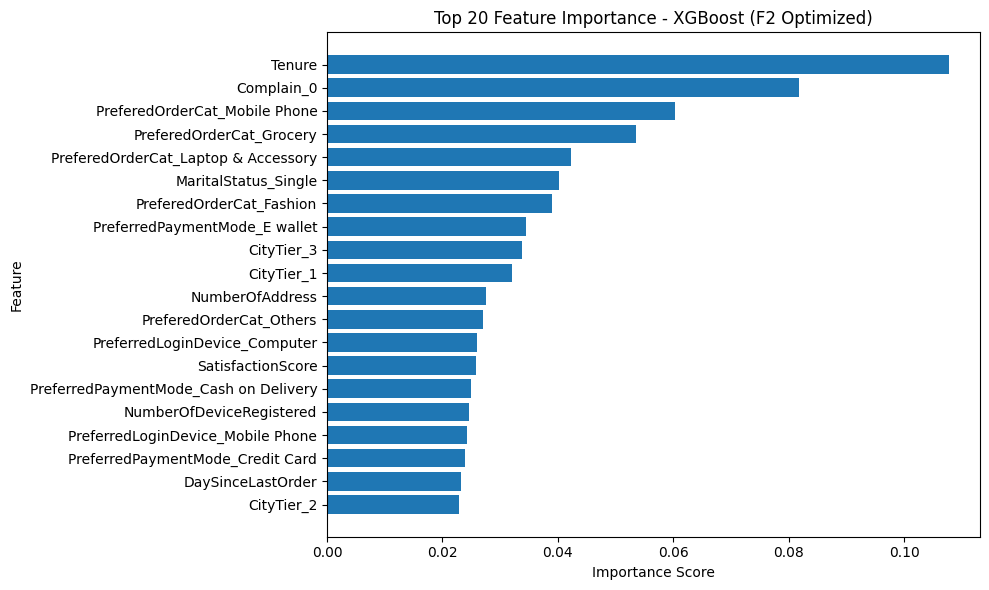

In [131]:
TOP_N = 20

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df['feature'][:TOP_N][::-1],
    feature_importance_df['importance'][:TOP_N][::-1]
)
plt.title('Top 20 Feature Importance - XGBoost (F2 Optimized)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


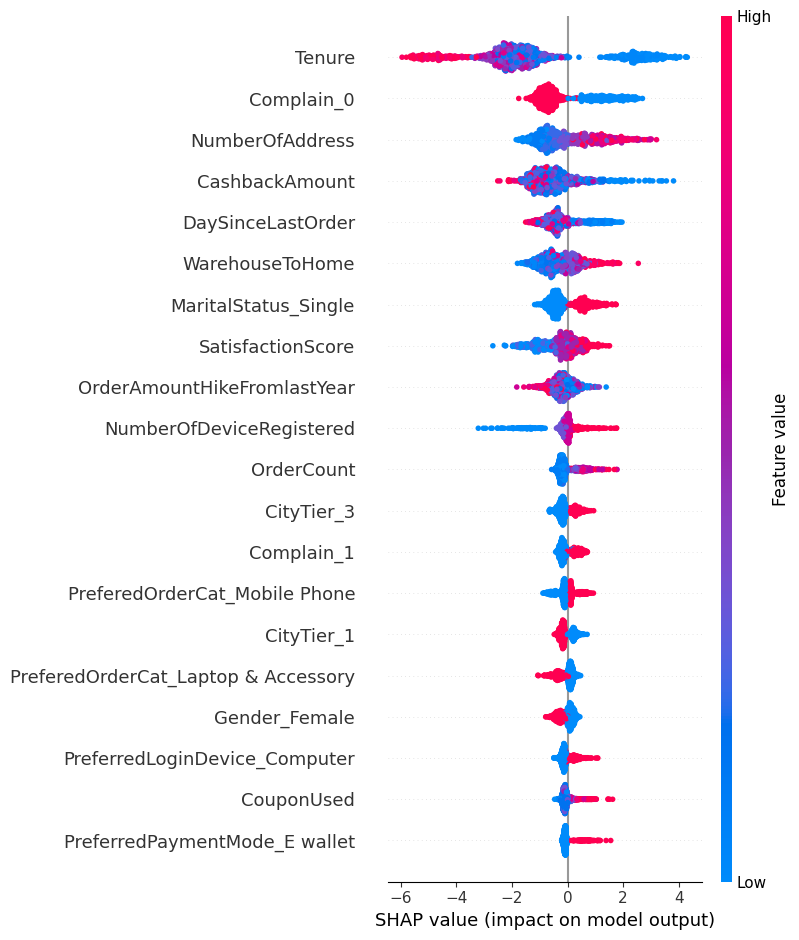

In [132]:
# SHAP
import shap

preprocessor = best_model_xgb.named_steps['preprocess']
model = best_model_xgb.named_steps['model']

X_test_transformed = preprocessor.transform(X_test)

feature_names = get_feature_names(preprocessor)

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed_df)



shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    plot_type="dot",
    max_display=20
)




## Analisis Feature Importances & SHAP pada Churn

Berdasarkan analisis SHAP diatas, fitur **Tenure** menjadi fitur yang sangat penting, di mana nilai yang tinggi (lama berlangganan) cenderung mendorong loyalitas, sementara nilai rendah terkait dengan risiko churn yang lebih tinggi.

Nilai rendah pada fitur **Complain_0** (ditandai warna biru) mendorong prediksi churn, sedangkan nilai tinggi (warna merah) justru mendorong prediksi loyal (nilai SHAP negatif). Fitur ini bersifat biner dengan nilai 0 atau 1, di mana nilai 0 menunjukkan pelanggan tidak mengajukan komplain sehingga cenderung loyal.

Selanjutnya untuk fitur **NumberOfAddress**, nilai yang tinggi mendorong prediksi churn (SHAP positif), yang dapat diartikan bahwa pelanggan dengan banyak alamat berpotensi lebih rentan untuk churn.

Pada fitur **CashbackAmount**, nilai rendah mendorong churn (SHAP negatif ke kiri), sementara nilai tinggi cenderung menunjukkan loyalitas pelanggan.

Fitur **DaySinceLastOrder** menunjukkan bahwa nilai rendah mendorong churn (SHAP positif ke kanan), artinya pelanggan cenderung berisiko churn pada saat kurun waktu yang cepat.

Jarak dari gudang ke rumah, yang direpresentasikan oleh fitur **WarehouseToHome**, juga memiliki efek yang serupa yaitu nilai yang tinggi mendorong churn.

Sementara itu, **SatisfactionScore** menunjukkan tren kebalikan, di mana nilai tinggi mengindikasikan potensial churn yang tinggi.


Beberapa fitur kategorikal juga berpengaruh, antara lain:  
- **MaritalStatus_Single**: Pelanggan yang single (nilai tinggi) cenderung churn (SHAP positif).  
- **PreferredLoginDevice_Computer**: Penggunaan komputer sebagai device login memengaruhi prediksi churn.  
- **CityTier_3** dan **CityTier_1**: Lokasi pelanggan berdampak pada kemungkinan churn.  
- **PreferredPaymentMode_Credit Card** dan **E_wallet**: Mode pembayaran juga menjadi faktor dalam prediksi churn.

### Kesimpulan

- Fitur-fitur terpenting yang memengaruhi prediksi churn adalah **Tenure**, **Complain_0**, **NumberOfAddress**, **CashbackAmount**, **DaySinceLastOrder**, dan **SatisfactionScore**. Model menggunakan kombinasi fitur numerik dan kategorikal dengan pola yang masuk akal secara bisnis, seperti pelanggan yang sudah lama (tenure tinggi) dan memiliki tingkat kepuasan tinggi cenderung lebih loyal, sedangkan pelanggan dengan perilaku sebaliknya lebih berisiko churn.


## **Limitasi**

1. Online - Ecommerce (Kompetitif)
Model dibangun hanya berdasarkan pola data historis, sehingga performanya dapat menurun apabila terjadi perubahan signifikan pada perilaku pelanggan, strategi bisnis, atau kondisi pasar yang sangat fluktuatif. 

2. Variabel Complain Bersifat Biner Yes/No (Tidak Kompleks) 
Fitur Complain hanya direpresentasikan dalam bentuk Yes/No, sehingga model tidak menangkap jenis keluhan, tingkat keparahan, maupun kualitas penanganan keluhan. Semua keluhan diperlakukan memiliki dampak yang sama terhadap risiko churn.

3. Analisis Cost-Benefit menggunakan asumsi biaya flat (Rp 450rb dan Rp 112,5rb). Dalam realitanya, nilai hidup setiap pelanggan (Customer Lifetime Value) berbeda-beda, kehilangan pelanggan premium (transaksi besar) tentu lebih merugikan daripada pelanggan yang jarang belanja.

4. Fitur Perilaku Bersifat Agregat (Akumulasi Data Historis)
Variabel seperti Tenure, OrderCount, dan DaySinceLastOrder merepresentasikan kondisi agregat, bukan dinamika perubahan perilaku pelanggan secara temporal (time-series) seperti date time. 

5. Model Bersifat Prediktif, Bukan Kausal
Model mampu mengidentifikasi pelanggan berisiko churn, namun tidak dapat memastikan bahwa suatu tindakan retensi tertentu secara langsung menyebabkan penurunan churn tanpa validasi lanjutan (misalnya A/B testing). Untuk saat ini, model ini hanya mampu melakukan generalisir antar segmen yang terbatas (perilaku churn tidak tertangkap optimal). 

In [133]:
import pickle

# Simpan pipeline ke file
with open('ECommerceChurn.pkl', 'wb') as file:
    pickle.dump(best_model_xgb, file)
